In [ ]:
# ── Adaptive testing generation — runs until you interrupt the kernel ───────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os, time, math, random
import numpy as np, pandas as pd
import aabpl.config as cfg
from aabpl.testing.perf_benchmark import run_single_config, save_run_result, load_results
from aabpl.radius_search.spacing_topology import compute_spatial_stats, SPACINGS_BREAKPOINTS
from aabpl.utils.crs_transformation import convert_pts_to_crs
import random
import itertools

cfg.PROFILE_FUNC_TIMES = False          # coarse timing only (func_timer_dict stays tiny)
crs, local_crs, COL = "EPSG:4326", "EPSG:32616", "employment"

# ── 1. datasets: real + artificial distributions ───────────────────────────
_base = pd.read_csv('../../cbsa_sample_data/plants_16980.txt', sep=",", header=None)
_base.columns = ["eid","employment","industry","lat","lon","moved"]
lat0,lat1,lon0,lon1 = _base.lat.min(),_base.lat.max(),_base.lon.min(),_base.lon.max()

def make_dataset(kind, n, seed=0):
    rng = np.random.default_rng(seed)
    if kind == "real":
        return _base.sample(min(n,len(_base)), random_state=seed).reset_index(drop=True)
    if kind == "uniform":
        lat, lon = rng.uniform(lat0,lat1,n), rng.uniform(lon0,lon1,n)
    elif kind == "gaussian":                       # several dense blobs (moderate skew)
        k=8; idx=rng.integers(0,k,n); cl=rng.uniform(lat0,lat1,k); co=rng.uniform(lon0,lon1,k)
        lat=rng.normal(cl[idx],(lat1-lat0)*0.02); lon=rng.normal(co[idx],(lon1-lon0)*0.02)
    elif kind == "skewed":                          # one dense core + sparse background (high skew)
        m=int(n*0.7)
        lat=np.r_[rng.normal((lat0+lat1)/2,(lat1-lat0)*0.01,m), rng.uniform(lat0,lat1,n-m)]
        lon=np.r_[rng.normal((lon0+lon1)/2,(lon1-lon0)*0.01,m), rng.uniform(lon0,lon1,n-m)]
    return pd.DataFrame({"eid":np.arange(n),"employment":rng.integers(1,50,n).astype(float),
                         "industry":0,"lat":lat,"lon":lon,"moved":9999})

# ── 2. parameter space (edit freely) ────────────────────────────────────────
DATASET_KINDS  = ["real","uniform","gaussian","skewed"]
RADII          = [250, 750, 3000]
SPACING_RATIOS = SPACINGS_BREAKPOINTS#[2**.5, 1.5, 2.5**.5, 2.0, 2.5]
NEST_DEPTHS    = [0,1,2,3,4]
SAMPLE_SIZES   = [20_000, 50_000, 250_000, 1_000_000]
FLAGS = dict(use_int_cell_keys=True, vectorized_search_loop=True, batch_overlap=True)  # production path

# ── 3. fresh generation (older results ignored) ────────────────────────────
GEN_FOLDER = "./perf_test_gen"; os.makedirs(GEN_FOLDER, exist_ok=True)
GENERATION = "gen" + time.strftime("%Y%m%d%H%M%S")
print("generation", GENERATION, "->", os.path.abspath(GEN_FOLDER), "\nInterrupt the kernel to stop.\n")

_ds, _stat = {}, {}
def get_dataset(kind,n):
    _ds.setdefault((kind,n), make_dataset(kind,n,seed=(abs(hash((kind,n)))%1000)))
    return _ds[(kind,n)]
def get_stats(kind,n,r):
    key=(kind,n,r)
    if key not in _stat:
        pp=get_dataset(kind,n).copy()
        xp,yp,_=convert_pts_to_crs(pts=pp,x="lon",y="lat",initial_crs=crs,target_crs=local_crs,silent=True)
        _stat[key]=compute_spatial_stats(target_points=pp[[xp,yp]].values, search_radii=[r])
    return _stat[key]
def feat(c):
    kind,n,r,sr,nd=c; st=get_stats(kind,n,r)
    w,h=st.get("spatial_width",1),st.get("spatial_height",1); sk=st.get("density_skewness_max_to_mean",1)
    return np.array([math.log(sr), nd, math.log(n), math.log(max(w*h,1e-9)), math.log(max(sk,1e-9)), math.log(r)])


# 1. Alle eindeutigen (sr, nd) Paare generieren
sr_nd_pairs = list(itertools.product(SPACING_RATIOS, NEST_DEPTHS))


# 2. Die Reihenfolge der Paare zufällig durchmischen
random.seed(0)
# random.shuffle(sr_nd_pairs)
sr_nd_pairs.sort(key=lambda pair: pair[0]*0.25 + pair[1]*1.0 + random.uniform(0, max(NEST_DEPTHS)))

# 3. Die finale Liste aufbauen (Gruppen bleiben intern zusammen)
ALL = [
    (k, n, r, sr, nd)
    for sr, nd in sr_nd_pairs
    for k in DATASET_KINDS
    for r in RADII
    for n in SAMPLE_SIZES
]
print("ALL", ALL)
# ALL=[(k,n,r,sr,nd) for k in DATASET_KINDS for n in SAMPLE_SIZES for r in RADII
#                     for sr in SPACING_RATIOS for nd in NEST_DEPTHS]
# random.seed(0); random.shuffle(ALL)
done=set(); Xd=[]; EPS=0.2; i=0

# ── 4. adaptive loop: max-coverage (farthest-point) + epsilon exploration ───
try:
    while True:
        rem=[c for c in ALL if c not in done]
        if not rem:                                   # full grid covered -> repeat for noise/averaging
            print("  (grid exhausted; repeating)"); done.clear(); Xd.clear(); rem=ALL[:]
        # if len(Xd) < 6 or random.random() < EPS:
        #     combo=random.choice(rem)                  # seed / explore
        # else:                                         # pick candidate farthest from sampled set
        #     A=np.array(Xd); mu,sd=A.mean(0),A.std(0)+1e-9; An=(A-mu)/sd
        #     best,bd=None,-1
        #     for c in random.sample(rem, min(len(rem),200)):
        #         d=((feat(c)-mu)/sd - An); d=(d*d).sum(1).min()
        #         if d>bd: bd,best=d,c
        #     combo=best
        combo = rem[0]
        kind,n,r,sr,nd=combo
        t0=time.perf_counter()
        try:
            d = get_dataset(kind,n)

            res=run_single_config(pts_source=d.sample(frac=random.uniform(0.5, 1.0)), crs=crs, radius=r,
                                   spacing_ratio=sr, nest_depth=nd, col=COL,
                                   pts_target=d.sample(frac=random.uniform(0.5, 1.0)), local_crs=local_crs,
                                   dist_stats=get_stats(kind,n,r), silent=True,
                                   generation=GENERATION, **FLAGS)
            save_run_result(res, GEN_FOLDER); done.add(combo); Xd.append(feat(combo)); i+=1
            print(f"[{i:4}] {kind:8} n={n:6} r={r:5} sr={sr:.3f} nd={nd}  "
                  f"cpu={res['timing']['total_cpu_s']:.2f}s  ({time.perf_counter()-t0:.1f}s)")
        except Exception as e:
            print(f"  ERR {combo}: {type(e).__name__}: {e}"); done.add(combo)
        if i and i%25==0:
            print(f"   -- {len(load_results(GEN_FOLDER, generation=GENERATION))} runs saved this generation --")
except KeyboardInterrupt:
    print(f"\nstopped after {i} runs. Fit with: df = load_results('{GEN_FOLDER}')  # only_new=True -> this generation")

generation gen20260618141327 -> z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test_gen 
Interrupt the kernel to stop.

ALL [('real', 20000, 250, np.float64(2.5495097567963922), 0), ('real', 50000, 250, np.float64(2.5495097567963922), 0), ('real', 100000, 250, np.float64(2.5495097567963922), 0), ('real', 500000, 250, np.float64(2.5495097567963922), 0), ('real', 20000, 750, np.float64(2.5495097567963922), 0), ('real', 50000, 750, np.float64(2.5495097567963922), 0), ('real', 100000, 750, np.float64(2.5495097567963922), 0), ('real', 500000, 750, np.float64(2.5495097567963922), 0), ('real', 20000, 3000, np.float64(2.5495097567963922), 0), ('real', 50000, 3000, np.float64(2.5495097567963922), 0), ('real', 100000, 3000, np.float64(2.5495097567963922), 0), ('real', 500000, 3000, np.float64(2.5495097567963922), 0), ('real', 20000, 250, np.float64(2.9154759474226504), 0), ('real', 50000, 250, np.float64(2.9154759474226504), 0), ('real', 100000, 250, np.float64(2.9154759474226504), 0), ('real'

In [13]:
pts_target.index, pts_source.index

(RangeIndex(start=0, stop=3945468, step=1),
 RangeIndex(start=0, stop=2572696, step=1))

In [ ]:
sr, nd = choose_spacing_and_depth(
    r=r, n_pts_src=len(pts_source), n_pts_tgt=len(pts_target), pts_tgt_xy=pts_target[['']]
)

KeyError: "None of [Index([1716868, 2569316,  823351, 1313984,  258526, 1535815, 1655487, 1913202,\n       1154412, 2022043,\n       ...\n       2412155, 1871821,  402493, 1992640, 2041025, 2553247, 1614011,   15089,\n       1685354, 2089496],\n      dtype='int32', length=50000)] are in the [columns]"

In [14]:
pts_source.head()

,eid,employment,industry,lat,lon,moved
0,3090646,17.0,0,41.769629,-87.904434,9999
1,1852822,41.0,0,41.951266,-87.617359,9999
2,3288405,38.0,0,41.569136,-88.287042,9999
3,888890,23.0,0,41.708394,-87.917526,9999
4,250699,28.0,0,42.036910,-87.989557,9999


In [ ]:
from aabpl.utils.crs_transformation import convert_MultiPolygon_crs, convert_coords_to_local_crs, convert_pts_to_crs, convert_wgs_to_utm


Reproject from EPSG:4326 to EPSG:32616


'EPSG:32616'

In [16]:
pts_source.head()

,eid,employment,industry,lat,lon,moved,proj_lon,proj_lat
0,3090646,17.0,0,41.769629,-87.904434,9999,424827.020185,4.624594e+06
1,1852822,41.0,0,41.951266,-87.617359,9999,448832.734842,4.644550e+06
2,3288405,38.0,0,41.569136,-88.287042,9999,392693.111249,4.602739e+06
3,888890,23.0,0,41.708394,-87.917526,9999,423666.343241,4.617807e+06
4,250699,28.0,0,42.036910,-87.989557,9999,418094.163103,4.654348e+06


In [18]:
d = get_dataset(kind,n)
cfg.disk_region_cache.clear()

sr, nd = choose_spacing_and_depth(
    r=r, n_pts_src=len(pts_source), n_pts_tgt=len(pts_target), pts_tgt_xy=pts_target[['proj_lat','proj_lon']]
)
res=run_single_config(pts_source=pts_source, crs=crs, radius=r,
                        spacing_ratio=sr, nest_depth=nd, col=COL,
                        pts_target=pts_target, local_crs=local_crs,
                        dist_stats=get_stats(kind,n,r), silent=True,
                        generation=GENERATION, **FLAGS)

KeyError: "None of [Index(['proj_lat', 'proj_lon'], dtype='str')] are in the [columns]"

In [47]:
import gc
import sys

# 1. Jupyter-Verlaufsspeicher für Zellausgaben leeren (wichtiger Notebook-Trick)
sys.modules['IPython'].get_ipython().user_ns['_ih'] = []
sys.modules['IPython'].get_ipython().user_ns['_oh'] = {}

# 2. Den Garbage Collector dreimal hintereinander triggern
gc.collect()
gc.collect()
gc.collect()

0

In [48]:
import os
import psutil

# Speicher des aktuellen Prozesses in MB umrechnen
process = psutil.Process(os.getpid())
ram_verbrauch = process.memory_info().rss / (1024 ** 2)

print(f"Aktueller Python RAM-Verbrauch: {ram_verbrauch:.2f} MB")

Aktueller Python RAM-Verbrauch: 1372.05 MB


In [49]:
# ── Adaptive testing generation — runs until you interrupt the kernel ───────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os, time, math, random
import numpy as np, pandas as pd
import aabpl.config as cfg
from aabpl.testing.perf_benchmark import run_single_config, save_run_result, load_results
from aabpl.radius_search.spacing_topology import compute_spatial_stats, SPACINGS_BREAKPOINTS, choose_spacing_and_depth
from aabpl.utils.crs_transformation import convert_pts_to_crs
import random
import gc
import itertools

cfg.PROFILE_FUNC_TIMES = False          # coarse timing only (func_timer_dict stays tiny)
crs, local_crs, COL = "EPSG:4326", "EPSG:32616", "employment"

# ── 1. datasets: real + artificial distributions ───────────────────────────
_base = pd.read_csv('../../cbsa_sample_data/plants_16980.txt', sep=",", header=None)
_base.columns = ["eid","employment","industry","lat","lon","moved"]
lat0,lat1,lon0,lon1 = _base.lat.min(),_base.lat.max(),_base.lon.min(),_base.lon.max()

def make_dataset(kind, n, seed=0):
    rng = np.random.default_rng(seed)
    if kind == "real":
        return _base.sample(min(n,len(_base)), random_state=seed).reset_index(drop=True)
    if kind == "uniform":
        lat, lon = rng.uniform(lat0,lat1,n), rng.uniform(lon0,lon1,n)
    elif kind == "gaussian":                       # several dense blobs (moderate skew)
        k=8; idx=rng.integers(0,k,n); cl=rng.uniform(lat0,lat1,k); co=rng.uniform(lon0,lon1,k)
        lat=rng.normal(cl[idx],(lat1-lat0)*0.02); lon=rng.normal(co[idx],(lon1-lon0)*0.02)
    elif kind == "skewed":                          # one dense core + sparse background (high skew)
        m=int(n*0.7)
        lat=np.r_[rng.normal((lat0+lat1)/2,(lat1-lat0)*0.01,m), rng.uniform(lat0,lat1,n-m)]
        lon=np.r_[rng.normal((lon0+lon1)/2,(lon1-lon0)*0.01,m), rng.uniform(lon0,lon1,n-m)]
    return pd.DataFrame({"eid":np.arange(n),"employment":rng.integers(1,50,n).astype(float),
                         "industry":0,"lat":lat,"lon":lon,"moved":9999})

# ── 2. parameter space (edit freely) ────────────────────────────────────────
DATASET_KINDS  = ["real","uniform","gaussian","skewed"][1:2]
RADII          = [750]
SAMPLE_SIZES   = [1_000, 50_000, 250_000, 1_000_000, 3_000_000, 5_000_000]
FLAGS = dict(use_int_cell_keys=True, vectorized_search_loop=True, batch_overlap=True)  # production path

# ── 3. fresh generation (older results ignored) ────────────────────────────
GEN_FOLDER = "./perf_test_gen"; os.makedirs(GEN_FOLDER, exist_ok=True)
GENERATION = "gen" + time.strftime("%Y%m%d%H%M%S")
print("generation", GENERATION, "->", os.path.abspath(GEN_FOLDER), "\nInterrupt the kernel to stop.\n")

_ds, _stat = {}, {}
def get_dataset(kind,n):
    _ds.setdefault((kind,n), make_dataset(kind,n,seed=(abs(hash((kind,n)))%1000)))
    return _ds[(kind,n)]
def get_stats(kind,n,r):
    key=(kind,n,r)
    if key not in _stat:
        pp=get_dataset(kind,n).copy()
        xp,yp,_=convert_pts_to_crs(pts=pp,x="lon",y="lat",initial_crs=crs,target_crs=local_crs,silent=True)
        _stat[key]=compute_spatial_stats(target_points=pp[[xp,yp]].values, search_radii=[r])
    return _stat[key]
def feat(c):
    kind,n_tgt,r,sr,nd=c; st=get_stats(kind,n,r)
    w,h=st.get("spatial_width",1),st.get("spatial_height",1); sk=st.get("density_skewness_max_to_mean",1)
    return np.array([math.log(sr), nd, math.log(n), math.log(max(w*h,1e-9)), math.log(max(sk,1e-9)), math.log(r)])


# 3. Die finale Liste aufbauen (Gruppen bleiben intern zusammen)
ALL = [
    (k, n_src, n_tgt, r)
    for k in DATASET_KINDS
    for r in RADII
    for n_src in SAMPLE_SIZES
    for n_tgt in SAMPLE_SIZES
][::-1]
print("ALL", ALL)
# ALL=[(k,n,r,sr,nd) for k in DATASET_KINDS for n in SAMPLE_SIZES for r in RADII
#                     for sr in SPACING_RATIOS for nd in NEST_DEPTHS]
# random.seed(0); random.shuffle(ALL)
done=set(); Xd=[]; EPS=0.2; i=0

# ── 4. adaptive loop: max-coverage (farthest-point) + epsilon exploration ───
try:
    rem = [c for c in ALL]
    while True:
        # rem=[c for c in ALL if c not in done]
        if not rem:
            rem = [c for c in ALL]
            # full grid covered -> repeat for noise/averaging
            print("  (grid exhausted; repeating)"); done.clear(); Xd.clear(); rem=ALL[:]
        # if len(Xd) < 6 or random.random() < EPS:
        #     combo=random.choice(rem)                  # seed / explore
        # else:                                         # pick candidate farthest from sampled set
        #     A=np.array(Xd); mu,sd=A.mean(0),A.std(0)+1e-9; An=(A-mu)/sd
        #     best,bd=None,-1
        #     for c in random.sample(rem, min(len(rem),200)):
        #         d=((feat(c)-mu)/sd - An); d=(d*d).sum(1).min()
        #         if d>bd: bd,best=d,c
        #     combo=best
        # combo = rem[0]
        kind,n_src,n_tgt,r =rem.pop(0)
        
        t0=time.perf_counter()
        # try:
        d = get_dataset(kind,max(n_src,n_tgt))
        pts_target=d.sample(n_src).copy().reset_index(drop=True)
        pts_source=d.sample(n_tgt).copy().reset_index(drop=True)
        convert_coords_to_local_crs(
            pts=pts_target,
            x = 'lon',
            y = 'lat',
            proj_x = 'proj_lon',
            proj_y = 'proj_lat',
            initial_crs = "EPSG:4326",
            target_crs = 'auto',
            )
        cfg.disk_region_cache.clear()
        s, nd = choose_spacing_and_depth(
            r=r, n_pts_src=len(pts_source), n_pts_tgt=len(pts_target), pts_tgt_xy=pts_target[['proj_lat','proj_lon']].values
        )
        sr=r/s
        combo=(kind,n_src,n_tgt,r,sr,nd)
        res=run_single_config(pts_source=pts_source, crs=crs, radius=r,
                                spacing_ratio=sr, nest_depth=nd, col=COL,
                                pts_target=pts_target, local_crs=local_crs,
                                dist_stats=get_stats(kind,n,r), silent=True,
                                generation=GENERATION, **FLAGS)
        del d
        del pts_target
        del pts_source

        # Direkt freigeben
        gc.collect()
        res['optimal_choice'] = True
        save_run_result(res, GEN_FOLDER); done.add((kind,n,r)); Xd.append(feat((kind,n_tgt,r,sr,nd))); i+=1
        print(f"[{i:4}/{len(ALL):5}] {kind:8} n_src={n_src:6} n_tgt={n_tgt:6} r={r:5} sr={sr:.3f} nd={nd}  "
                f"cpu={res['timing']['total_cpu_s']:.2f}s  ({time.perf_counter()-t0:.1f}s)")
        # except Exception as e:
        #     print(f"  ERR {combo}: {type(e).__name__}: {e}"); done.add((kind,n,r))
        if i and i%25==0:
            print(f"   -- {len(load_results(GEN_FOLDER, generation=GENERATION))} runs saved this generation --")
except KeyboardInterrupt:
    print(f"\nstopped after {i} runs. Fit with: df = load_results('{GEN_FOLDER}')  # only_new=True -> this generation")

generation gen20260618231923 -> z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test_gen 
Interrupt the kernel to stop.

ALL [('uniform', 5000000, 5000000, 750), ('uniform', 5000000, 3000000, 750), ('uniform', 5000000, 1000000, 750), ('uniform', 5000000, 250000, 750), ('uniform', 5000000, 50000, 750), ('uniform', 5000000, 1000, 750), ('uniform', 3000000, 5000000, 750), ('uniform', 3000000, 3000000, 750), ('uniform', 3000000, 1000000, 750), ('uniform', 3000000, 250000, 750), ('uniform', 3000000, 50000, 750), ('uniform', 3000000, 1000, 750), ('uniform', 1000000, 5000000, 750), ('uniform', 1000000, 3000000, 750), ('uniform', 1000000, 1000000, 750), ('uniform', 1000000, 250000, 750), ('uniform', 1000000, 50000, 750), ('uniform', 1000000, 1000, 750), ('uniform', 250000, 5000000, 750), ('uniform', 250000, 3000000, 750), ('uniform', 250000, 1000000, 750), ('uniform', 250000, 250000, 750), ('uniform', 250000, 50000, 750), ('uniform', 250000, 1000, 750), ('uniform', 50000, 5000000, 750), ('uni

In [ ]:
id_to_sums_by_lvl 

In [ ]:
# ── Adaptive testing generation — runs until you interrupt the kernel ───────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os, time, math, random
import numpy as np, pandas as pd
import aabpl.config as cfg
from aabpl.testing.perf_benchmark import run_single_config, save_run_result, load_results
from aabpl.radius_search.spacing_topology import compute_spatial_stats, SPACINGS_BREAKPOINTS, choose_spacing_and_depth
from aabpl.utils.crs_transformation import convert_pts_to_crs
import random
import gc
import itertools

cfg.PROFILE_FUNC_TIMES = False          # coarse timing only (func_timer_dict stays tiny)
crs, local_crs, COL = "EPSG:4326", "EPSG:32616", "employment"

# ── 1. datasets: real + artificial distributions ───────────────────────────
_base = pd.read_csv('../../cbsa_sample_data/plants_16980.txt', sep=",", header=None)
_base = pd.read_csv('../../cbsa_sample_data/plants_10180.txt', sep=",", header=None)
_base.columns = ["eid","employment","industry","lat","lon","moved"]
lat0,lat1,lon0,lon1 = _base.lat.min(),_base.lat.max(),_base.lon.min(),_base.lon.max()

def make_dataset(kind, n, seed=0):
    rng = np.random.default_rng(seed)
    if kind == "real":
        return _base.sample(min(n,len(_base)), random_state=seed).reset_index(drop=True)
    if kind == "uniform":
        lat, lon = rng.uniform(lat0,lat1,n), rng.uniform(lon0,lon1,n)
    elif kind == "gaussian":                       # several dense blobs (moderate skew)
        k=8; idx=rng.integers(0,k,n); cl=rng.uniform(lat0,lat1,k); co=rng.uniform(lon0,lon1,k)
        lat=rng.normal(cl[idx],(lat1-lat0)*0.02); lon=rng.normal(co[idx],(lon1-lon0)*0.02)
    elif kind == "skewed":                          # one dense core + sparse background (high skew)
        m=int(n*0.7)
        lat=np.r_[rng.normal((lat0+lat1)/2,(lat1-lat0)*0.01,m), rng.uniform(lat0,lat1,n-m)]
        lon=np.r_[rng.normal((lon0+lon1)/2,(lon1-lon0)*0.01,m), rng.uniform(lon0,lon1,n-m)]
    return pd.DataFrame({"eid":np.arange(n),"employment":rng.integers(1,50,n).astype(float),
                         "industry":0,"lat":lat,"lon":lon,"moved":9999})

# ── 2. parameter space (edit freely) ────────────────────────────────────────
DATASET_KINDS  = ["real","uniform","gaussian","skewed"][1:2]
RADII          = [750]
SAMPLE_SIZES   = [20_000, 100_000, 300_000, 500_000]
FLAGS = dict(use_int_cell_keys=True, vectorized_search_loop=True, batch_overlap=True)  # production path

# ── 3. fresh generation (older results ignored) ────────────────────────────
GEN_FOLDER = "./perf_test_gen"; os.makedirs(GEN_FOLDER, exist_ok=True)
GENERATION = "gen" + time.strftime("%Y%m%d%H%M%S")
print("generation", GENERATION, "->", os.path.abspath(GEN_FOLDER), "\nInterrupt the kernel to stop.\n")

_ds, _stat = {}, {}
def get_dataset(kind,n):
    _ds.setdefault((kind,n), make_dataset(kind,n,seed=(abs(hash((kind,n)))%1000)))
    return _ds[(kind,n)]
def get_stats(kind,n,r):
    key=(kind,n,r)
    if key not in _stat:
        pp=get_dataset(kind,n).copy()
        xp,yp,_=convert_pts_to_crs(pts=pp,x="lon",y="lat",initial_crs=crs,target_crs=local_crs,silent=True)
        _stat[key]=compute_spatial_stats(target_points=pp[[xp,yp]].values, search_radii=[r])
    return _stat[key]
def feat(c):
    kind,n_tgt,r,sr,nd=c; st=get_stats(kind,n,r)
    w,h=st.get("spatial_width",1),st.get("spatial_height",1); sk=st.get("density_skewness_max_to_mean",1)
    return np.array([math.log(sr), nd, math.log(n), math.log(max(w*h,1e-9)), math.log(max(sk,1e-9)), math.log(r)])


# 3. Die finale Liste aufbauen (Gruppen bleiben intern zusammen)
ALL = [
    (k, n_src, n_tgt, r, optimize, oldsearch, usecodex)
    for k in DATASET_KINDS
    for r in RADII
    for n_src in SAMPLE_SIZES
    for n_tgt in SAMPLE_SIZES
    for optimize in [False, True]
    for oldsearch in [False]
    for usecodex in [True]
]
print("ALL", ALL)
# ALL=[(k,n,r,sr,nd) for k in DATASET_KINDS for n in SAMPLE_SIZES for r in RADII
#                     for sr in SPACING_RATIOS for nd in NEST_DEPTHS]
# random.seed(0); random.shuffle(ALL)
done=set(); Xd=[]; EPS=0.2; i=0

# ── 4. adaptive loop: max-coverage (farthest-point) + epsilon exploration ───
try:
    rem = [c for c in ALL]
    while True:
        
        # rem=[c for c in ALL if c not in done]
        if not rem:
            rem = [c for c in ALL]
            break
            # full grid covered -> repeat for noise/averaging
            print("  (grid exhausted; repeating)"); done.clear(); Xd.clear(); rem=ALL[:]
        # if len(Xd) < 6 or random.random() < EPS:
        #     combo=random.choice(rem)                  # seed / explore
        # else:                                         # pick candidate farthest from sampled set
        #     A=np.array(Xd); mu,sd=A.mean(0),A.std(0)+1e-9; An=(A-mu)/sd
        #     best,bd=None,-1
        #     for c in random.sample(rem, min(len(rem),200)):
        #         d=((feat(c)-mu)/sd - An); d=(d*d).sum(1).min()
        #         if d>bd: bd,best=d,c
        #     combo=best
        # combo = rem[0]
        kind,n_src,n_tgt,r, optimize,oldsearch,usecodex =rem.pop(0)
        print(f"[{i:4}/{len(ALL):5}] usecodex={bool(usecodex):4} oldsearch={bool(oldsearch):4} optimize={bool(optimize):4} {kind:8} n_src={n_src:6} n_tgt={n_tgt:6} r={r:5} sr={sr:.3f} nd={nd}  ")
        #
        cfg.USE_OPTIMIZED_METHOD = optimize
        cfg.VALIDATE = True
        cfg.USE_OLD_DISKSEARCH = oldsearch
        t0=time.perf_counter()
        # try:
        d = get_dataset(kind,max(n_src,n_tgt))
        pts_target=d.sample(n_src).copy().reset_index(drop=True)
        pts_source=d.sample(n_tgt).copy().reset_index(drop=True)
        # pts_source=pts_target
        convert_coords_to_local_crs(
            pts=pts_target,
            x = 'lon',
            y = 'lat',
            proj_x = 'proj_lon',
            proj_y = 'proj_lat',
            initial_crs = "EPSG:4326",
            target_crs = 'auto',
            )
        # cfg.disk_region_cache.clear()
        s, nd = choose_spacing_and_depth(
            r=r, n_pts_src=len(pts_source), n_pts_tgt=len(pts_target), pts_tgt_xy=pts_target[['proj_lat','proj_lon']].values
        )
        sr=r/s
        combo=(kind,n_src,n_tgt,r,sr,nd)
        res=run_single_config(pts_source=pts_source, crs=crs, radius=r,
                                spacing_ratio=sr, nest_depth=nd, col=COL,
                                pts_target=pts_target, local_crs=local_crs,exclude_pt_itself=False,
                                dist_stats=get_stats(kind,n,r), silent=True,
                                generation=GENERATION, **FLAGS)
        del d
        del pts_target
        del pts_source

        # Direkt freigeben
        gc.collect()
        res['optimal_choice'] = True
        save_run_result(res, GEN_FOLDER); done.add((kind,n,r)); Xd.append(feat((kind,n_tgt,r,sr,nd))); i+=1
        print(f"[{i:4}/{len(ALL):5}] usecodex={bool(usecodex):4} oldsearch={bool(oldsearch):4} optimize={bool(optimize):4} {kind:8} n_src={n_src:6} n_tgt={n_tgt:6} r={r:5} sr={sr:.3f} nd={nd}  "
                f"cpu={res['timing']['total_cpu_s']:.2f}s  ({time.perf_counter()-t0:.1f}s)")
        # except Exception as e:
        #     print(f"  ERR {combo}: {type(e).__name__}: {e}"); done.add((kind,n,r))
        if i and i%25==0:
            print(f"   -- {len(load_results(GEN_FOLDER, generation=GENERATION))} runs saved this generation --")
except KeyboardInterrupt:
    print(f"\nstopped after {i} runs. Fit with: df = load_results('{GEN_FOLDER}')  # only_new=True -> this generation")

generation gen20260619095641 -> z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test_gen 
Interrupt the kernel to stop.

ALL [('uniform', 20000, 20000, 750, False, False, True), ('uniform', 20000, 20000, 750, True, False, True), ('uniform', 20000, 100000, 750, False, False, True), ('uniform', 20000, 100000, 750, True, False, True), ('uniform', 20000, 300000, 750, False, False, True), ('uniform', 20000, 300000, 750, True, False, True), ('uniform', 20000, 500000, 750, False, False, True), ('uniform', 20000, 500000, 750, True, False, True), ('uniform', 100000, 20000, 750, False, False, True), ('uniform', 100000, 20000, 750, True, False, True), ('uniform', 100000, 100000, 750, False, False, True), ('uniform', 100000, 100000, 750, True, False, True), ('uniform', 100000, 300000, 750, False, False, True), ('uniform', 100000, 300000, 750, True, False, True), ('uniform', 100000, 500000, 750, False, False, True), ('uniform', 100000, 500000, 750, True, False, True), ('uniform', 300000, 20000, 75

In [43]:
# ── Adaptive testing generation — runs until you interrupt the kernel ───────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os, time, math, random
import numpy as np, pandas as pd
import aabpl.config as cfg
from aabpl.testing.perf_benchmark import run_single_config, save_run_result, load_results
from aabpl.radius_search.spacing_topology import compute_spatial_stats, SPACINGS_BREAKPOINTS
from aabpl.utils.crs_transformation import convert_pts_to_crs
import random
import itertools

cfg.PROFILE_FUNC_TIMES = False          # coarse timing only (func_timer_dict stays tiny)
crs, local_crs, COL = "EPSG:4326", "EPSG:32616", "employment"

# ── 1. datasets: real + artificial distributions ───────────────────────────
_base = pd.read_csv('../../cbsa_sample_data/plants_16980.txt', sep=",", header=None)
_base.columns = ["eid","employment","industry","lat","lon","moved"]
lat0,lat1,lon0,lon1 = _base.lat.min(),_base.lat.max(),_base.lon.min(),_base.lon.max()

def make_dataset(kind, n, seed=0):
    rng = np.random.default_rng(seed)
    if kind == "real":
        return _base.sample(min(n,len(_base)), random_state=seed).reset_index(drop=True)
    if kind == "uniform":
        lat, lon = rng.uniform(lat0,lat1,n), rng.uniform(lon0,lon1,n)
    elif kind == "gaussian":                       # several dense blobs (moderate skew)
        k=8; idx=rng.integers(0,k,n); cl=rng.uniform(lat0,lat1,k); co=rng.uniform(lon0,lon1,k)
        lat=rng.normal(cl[idx],(lat1-lat0)*0.02); lon=rng.normal(co[idx],(lon1-lon0)*0.02)
    elif kind == "skewed":                          # one dense core + sparse background (high skew)
        m=int(n*0.7)
        lat=np.r_[rng.normal((lat0+lat1)/2,(lat1-lat0)*0.01,m), rng.uniform(lat0,lat1,n-m)]
        lon=np.r_[rng.normal((lon0+lon1)/2,(lon1-lon0)*0.01,m), rng.uniform(lon0,lon1,n-m)]
    return pd.DataFrame({"eid":np.arange(n),"employment":rng.integers(1,50,n).astype(float),
                         "industry":0,"lat":lat,"lon":lon,"moved":9999})

# ── 2. parameter space (edit freely) ────────────────────────────────────────
DATASET_KINDS  = ["real","uniform","gaussian","skewed"]
RADII          = [250, 750, 3000]
SPACING_RATIOS = SPACINGS_BREAKPOINTS#[2**.5, 1.5, 2.5**.5, 2.0, 2.5]
NEST_DEPTHS    = [0,1,2,3,4]
SAMPLE_SIZES   = [20_000, 50_000, 250_000, 1_000_000]
FLAGS = dict(use_int_cell_keys=True, vectorized_search_loop=True, batch_overlap=True)  # production path

# ── 3. fresh generation (older results ignored) ────────────────────────────
GEN_FOLDER = "./perf_test_gen"; os.makedirs(GEN_FOLDER, exist_ok=True)
GENERATION = "gen" + time.strftime("%Y%m%d%H%M%S")
print("generation", GENERATION, "->", os.path.abspath(GEN_FOLDER), "\nInterrupt the kernel to stop.\n")

_ds, _stat = {}, {}
def get_dataset(kind,n):
    _ds.setdefault((kind,n), make_dataset(kind,n,seed=(abs(hash((kind,n)))%1000)))
    return _ds[(kind,n)]
def get_stats(kind,n,r):
    key=(kind,n,r)
    if key not in _stat:
        pp=get_dataset(kind,n).copy()
        xp,yp,_=convert_pts_to_crs(pts=pp,x="lon",y="lat",initial_crs=crs,target_crs=local_crs,silent=True)
        _stat[key]=compute_spatial_stats(target_points=pp[[xp,yp]].values, search_radii=[r])
    return _stat[key]
def feat(c):
    kind,n,r,sr,nd=c; st=get_stats(kind,n,r)
    w,h=st.get("spatial_width",1),st.get("spatial_height",1); sk=st.get("density_skewness_max_to_mean",1)
    return np.array([math.log(sr), nd, math.log(n), math.log(max(w*h,1e-9)), math.log(max(sk,1e-9)), math.log(r)])


# 1. Alle eindeutigen (sr, nd) Paare generieren
sr_nd_pairs = list(itertools.product(SPACING_RATIOS, NEST_DEPTHS))


# 2. Die Reihenfolge der Paare zufällig durchmischen
random.seed(0)
# random.shuffle(sr_nd_pairs)
sr_nd_pairs.sort(key=lambda pair: pair[0]*0.25 + pair[1]*1.0 + random.uniform(0, max(NEST_DEPTHS)))

# 3. Die finale Liste aufbauen (Gruppen bleiben intern zusammen)
ALL = [
    (k, n, r, sr, nd)
    for sr, nd in sr_nd_pairs
    for k in DATASET_KINDS
    for r in RADII
    for n in SAMPLE_SIZES
]
print("ALL", ALL)
# ALL=[(k,n,r,sr,nd) for k in DATASET_KINDS for n in SAMPLE_SIZES for r in RADII
#                     for sr in SPACING_RATIOS for nd in NEST_DEPTHS]
# random.seed(0); random.shuffle(ALL)
done=set(); Xd=[]; EPS=0.2; i=0

# ── 4. adaptive loop: max-coverage (farthest-point) + epsilon exploration ───
try:
    while True:
        rem=[c for c in ALL if c not in done]
        if not rem:                                   # full grid covered -> repeat for noise/averaging
            print("  (grid exhausted; repeating)"); done.clear(); Xd.clear(); rem=ALL[:]
        # if len(Xd) < 6 or random.random() < EPS:
        #     combo=random.choice(rem)                  # seed / explore
        # else:                                         # pick candidate farthest from sampled set
        #     A=np.array(Xd); mu,sd=A.mean(0),A.std(0)+1e-9; An=(A-mu)/sd
        #     best,bd=None,-1
        #     for c in random.sample(rem, min(len(rem),200)):
        #         d=((feat(c)-mu)/sd - An); d=(d*d).sum(1).min()
        #         if d>bd: bd,best=d,c
        #     combo=best
        combo = rem[0]
        kind,n,r,sr,nd=combo
        t0=time.perf_counter()
        try:
            d = get_dataset(kind,n)
            
            res=run_single_config(pts_source=d.sample(frac=random.uniform(0.5, 1.0)), crs=crs, radius=r,
                                   spacing_ratio=sr, nest_depth=nd, col=COL,
                                   pts_target=d.sample(frac=random.uniform(0.5, 1.0)), local_crs=local_crs,
                                   dist_stats=get_stats(kind,n,r), silent=True,
                                   generation=GENERATION, **FLAGS)
            save_run_result(res, GEN_FOLDER); done.add(combo); Xd.append(feat(combo)); i+=1
            print(f"[{i:4}] {kind:8} n={n:6} r={r:5} sr={sr:.3f} nd={nd}  "
                  f"cpu={res['timing']['total_cpu_s']:.2f}s  ({time.perf_counter()-t0:.1f}s)")
        except Exception as e:
            print(f"  ERR {combo}: {type(e).__name__}: {e}"); done.add(combo)
        if i and i%25==0:
            print(f"   -- {len(load_results(GEN_FOLDER, generation=GENERATION))} runs saved this generation --")
except KeyboardInterrupt:
    print(f"\nstopped after {i} runs. Fit with: df = load_results('{GEN_FOLDER}')  # only_new=True -> this generation")

generation gen20260618213859 -> z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test_gen 
Interrupt the kernel to stop.

ALL [('real', 20000, 250, np.float64(2.5495097567963922), 0), ('real', 50000, 250, np.float64(2.5495097567963922), 0), ('real', 250000, 250, np.float64(2.5495097567963922), 0), ('real', 1000000, 250, np.float64(2.5495097567963922), 0), ('real', 20000, 750, np.float64(2.5495097567963922), 0), ('real', 50000, 750, np.float64(2.5495097567963922), 0), ('real', 250000, 750, np.float64(2.5495097567963922), 0), ('real', 1000000, 750, np.float64(2.5495097567963922), 0), ('real', 20000, 3000, np.float64(2.5495097567963922), 0), ('real', 50000, 3000, np.float64(2.5495097567963922), 0), ('real', 250000, 3000, np.float64(2.5495097567963922), 0), ('real', 1000000, 3000, np.float64(2.5495097567963922), 0), ('uniform', 20000, 250, np.float64(2.5495097567963922), 0), ('uniform', 50000, 250, np.float64(2.5495097567963922), 0), ('uniform', 250000, 250, np.float64(2.5495097567963922),

In [58]:
from pandas import read_csv

path_to_your_csv ='../../cbsa_sample_data/plants_16980.txt'
crs_of_your_csv =  "EPSG:4326"
pts1 = read_csv(path_to_your_csv, sep=",", header=None)#[:5000]
pts1.columns = ["eid", "employment", "industry", "lat","lon","moved"]



Reproject from EPSG:4326 to EPSG:32616


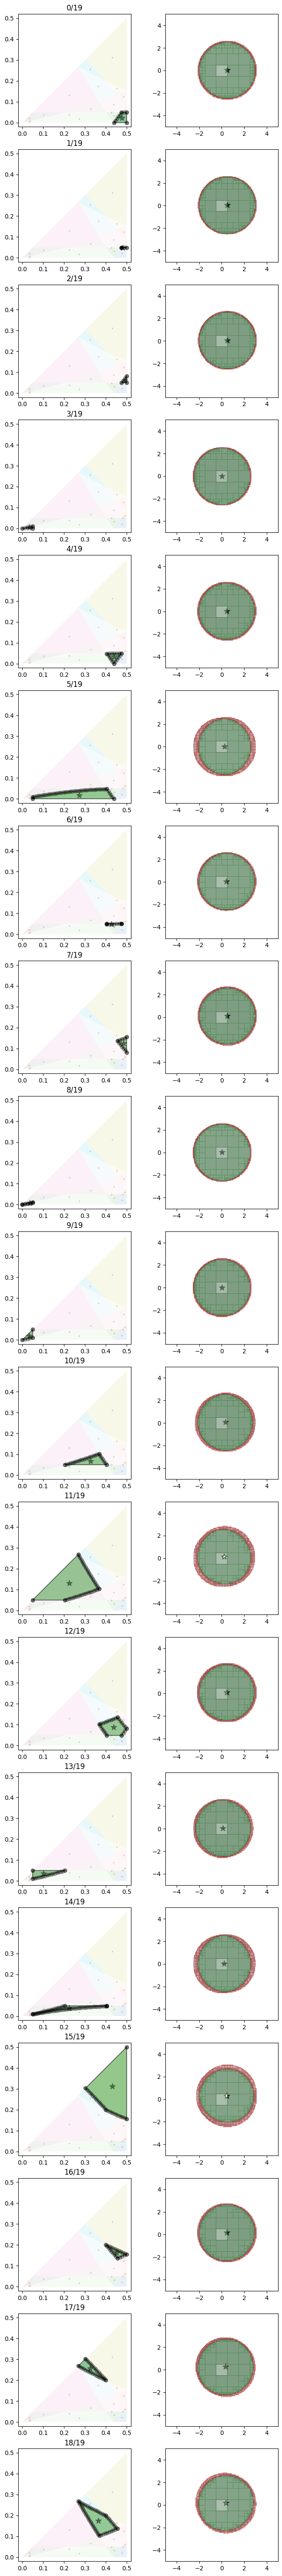

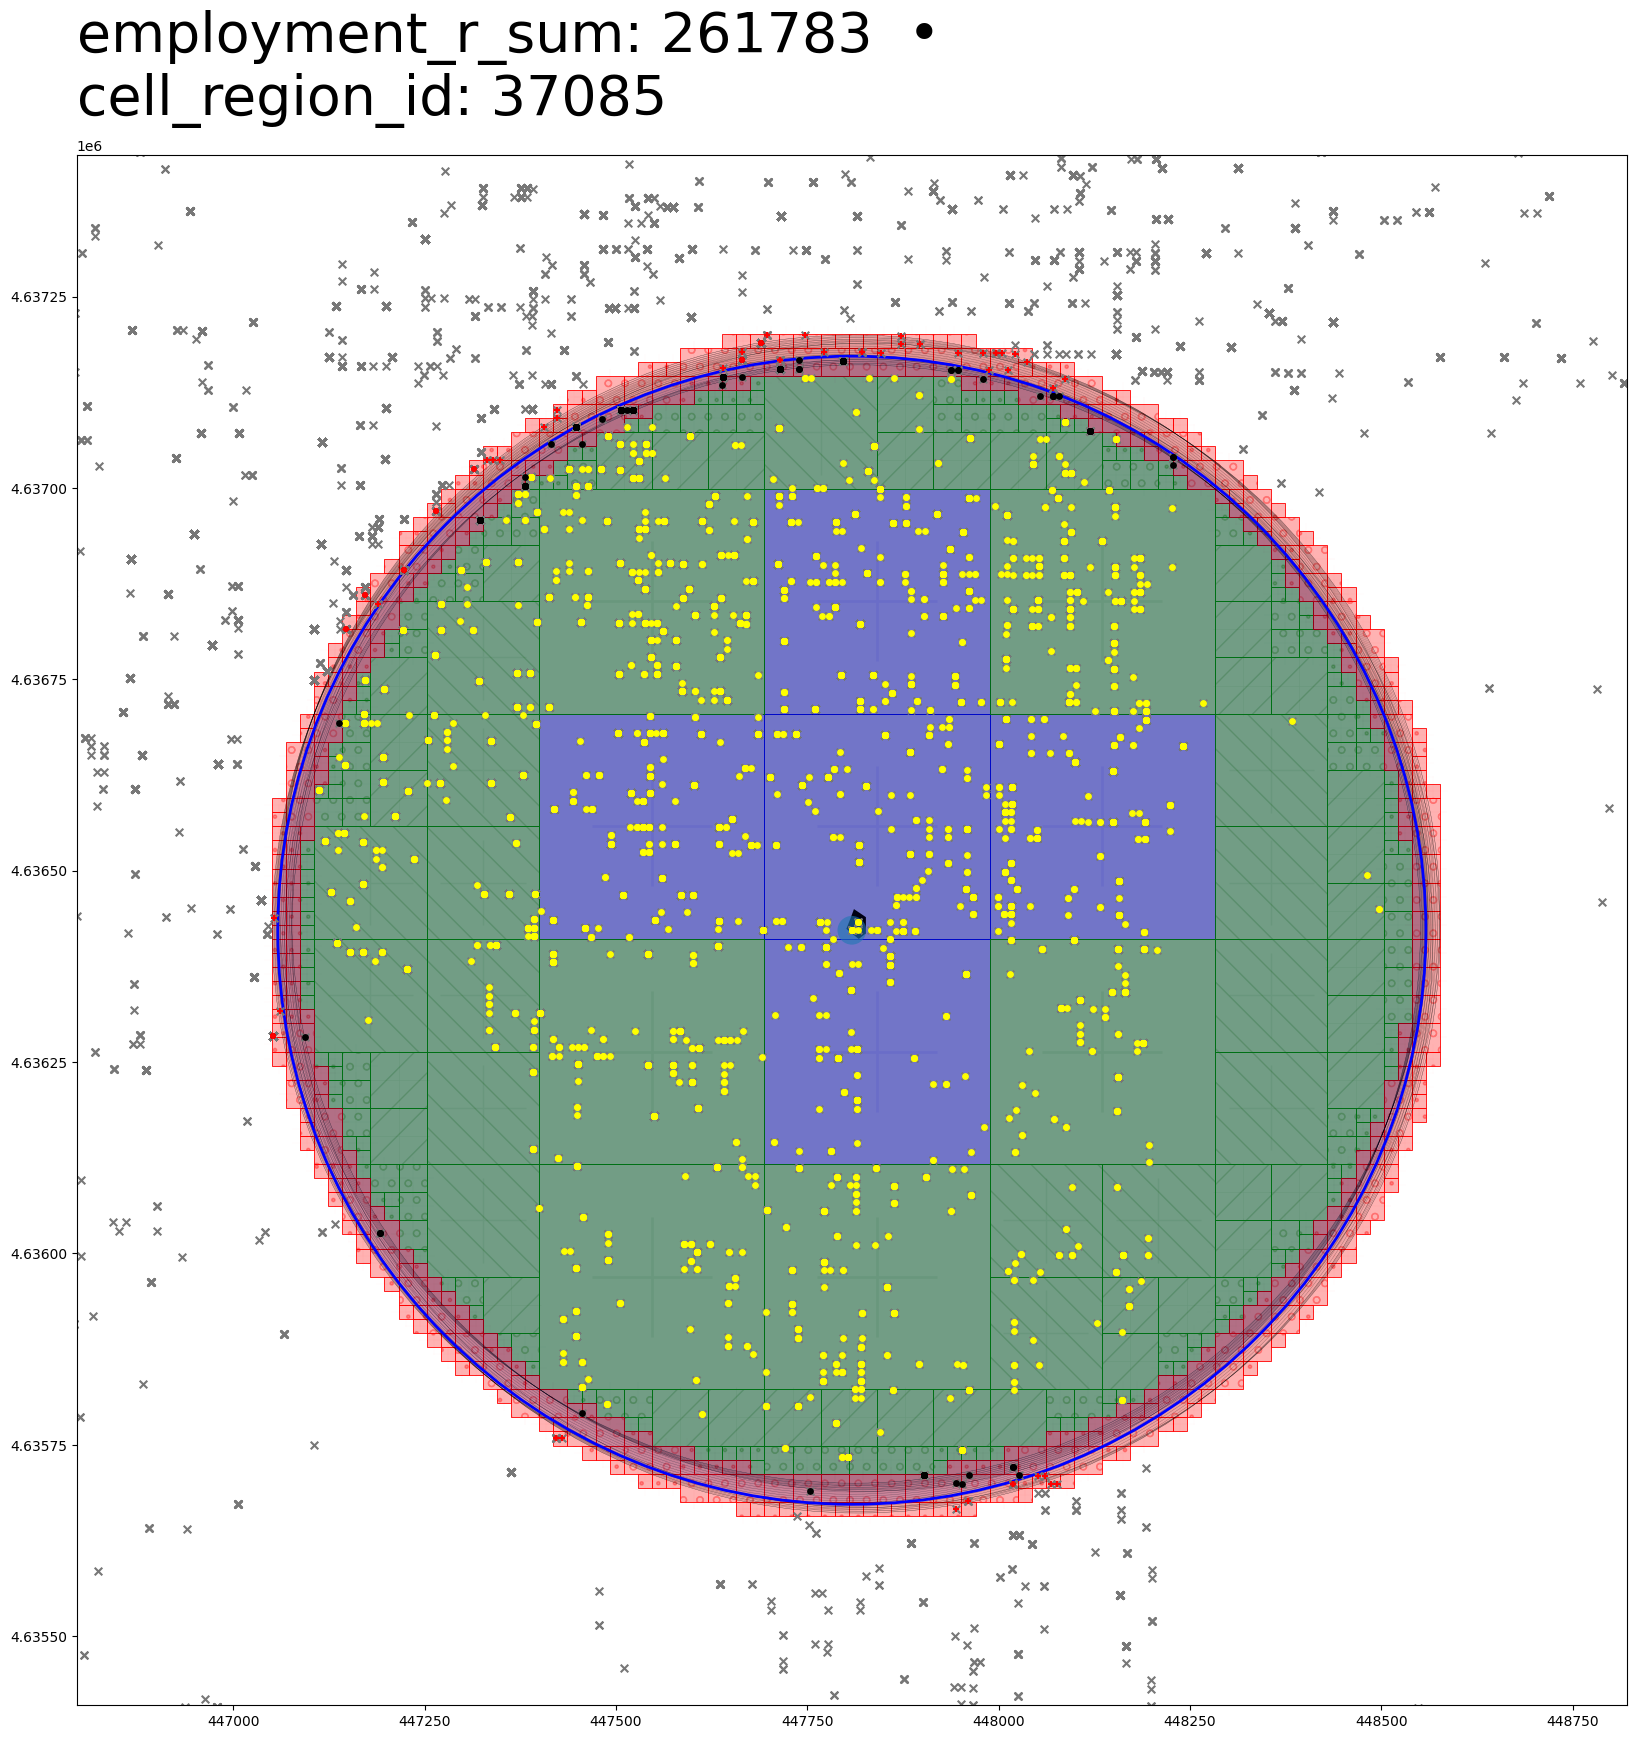

In [60]:
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
from aabpl import radius_search, detect_cluster_pts, detect_cluster_pts, Grid
from aabpl.testing.test_performance import analyze_func_perf, func_timer_dict, reset_perf_times
from aabpl import config
config.VAIDATE = True
# reset_perf_times()
r=750
spacing=750/2**.5-0.001
grid = radius_search(
    pts=pts1,
    crs=crs_of_your_csv,
    r=r,
    c='employment',
    exclude_pt_itself=True,
    silent=False,
    # grid=grid_m,
    _dev={'plot_pt_disk':{'pt_id':32553}, 'plot_offset_regions':{}},#32553-3
)
# perf_analysis = analyze_func_perf(plot=True)


In [62]:
cfg.disk_region_cache.keys()

odict_keys([(np.float64(1.5), 1, False)])

In [132]:
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
from aabpl import radius_search, detect_cluster_pts, detect_cluster_pts, Grid
from aabpl.testing.test_performance import analyze_func_perf, func_timer_dict, reset_perf_times
from aabpl import config
config.USE_OLD_DISKSEARCH = False
config.VALIDATE = True
config.USE_CODEX = True
# config.USE_CODEX = False
from pandas import read_csv

# path_to_your_csv ='../../cbsa_sample_data/plants_16980.txt'
path_to_your_csv ='../../cbsa_sample_data/plants_10180.txt'

crs_of_your_csv =  "EPSG:4326"
pts1 = read_csv(path_to_your_csv, sep=",", header=None)#[:5000]
pts1.columns = ["eid", "employment", "industry", "lat","lon","moved"]

grid = radius_search(
    pts=pts1,
    crs=crs_of_your_csv,
    r=r,
    c='employment',
    exclude_pt_itself=True,
    silent=False,
    # grid=grid_m,
    _dev={
        'plot_pt_disk':{'pt_id':25050 }, 
        # 'plot_offset_regions':{}
        },#32553 25050 
)

Reproject from EPSG:4326 to EPSG:32614
  radius_search    [>                 ]   5%  assigning target        15,161 pts      0.0s  ~24s left              codec not none
id_to_sums_by_lvl[:10] [(167320, array([2])), (1872957, array([2])), (3577288, array([2])), (167672, array([4])), (1868089, array([4])), (3569810, array([4])), (167768, array([2])), (1873401, array([2])), (3575122, array([2])), (177768, array([2]))]
  radius_search    [==>               ]  15%  searching               15,161 pts      22.8s  ~1m17s left           usenew
VALIDATION OK: all 49 cell_region(s) correct.


In [5]:
r=750
spacing=750/2**.5-0.001
grid = radius_search(
    pts=pts1,
    crs=crs_of_your_csv,
    r=r,
    c='employment',
    exclude_pt_itself=True,
    silent=True,
    # grid=grid_m,
    spacing=spacing,
    nest_depth=4,
    trynew = 2,
    # _dev={'plot_pt_disk':{'pt_id':32553}, 'plot_offset_regions':{}},#32553-3
)
# perf_analysis = analyze_

Reproject from EPSG:4326 to EPSG:32616


In [27]:
import sys
import pickle
from aabpl import config
# Quick shallow size (bytes)
# sys.getsizeof(config.disk_region_cache)

# Deep size including all referenced objects
len(pickle.dumps(config.disk_region_cache))


from pympler import asizeof
asizeof.asizeof(config.disk_region_cache)/1024**2
# per entry
for k, v in config.disk_region_cache.items():
    print(k,asizeof.asizeof(v)/1024**2, type(v))
    # for key, val in v[8].items():
    #     print()
    # for k0,x in v.items():

    #     print(type(x), asizeof.asizeof(x)/1024**2,round(asizeof.asizeof(x)/asizeof.asizeof(v),2))

(np.float64(2.54950976), 0, False) 1.5912628173828125 <class 'dict'>


---
## Performance Benchmarking

### Phase 1 — Sweep over optimization parameters

Run `radius_search` for every combination of `(radius, spacing, nest_depth, trynew)`.
Each completed run is saved immediately as a JSON file in `perf_test/`, so the sweep
is restartable and skips already-completed configurations.

**Scenario parameters** (the inputs you cannot choose):
- `search_radius` — the search radius
- point-cloud geometry captured by `calc_distribution_stats`

**Optimization parameters** (what we want to choose optimally):
- `spacing` — grid cell width (chosen from `generate_2d_breakpoints`)
- `nest_depth` — integer 0–9
- `trynew` — algorithm variant 0–3 (Phase 1 only; fixed after first sweep)

**Derived meta-parameters** captured per run:
- `calc_micro_region_stats` — average contained/overlapped cells per region  
  (depends only on the `radius/spacing` ratio, so reusable across point clouds)

In [12]:
# ── Combined search-loop test: group sizes + equivalence + G_MIN tuning ──────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os, time, statistics, hashlib
import numpy as np, pandas as pd
import aabpl.config as cfg
cfg.PROFILE_FUNC_TIMES = False
from aabpl.main import radius_search

path_to_csv = '../../cbsa_sample_data/plants_16980.txt'
COLS = ["eid", "employment", "industry", "lat", "lon", "moved"]
N = 100_000
RADII = [750, 1500, 3000]          # last (densest) used for parts 2 & 3
DENSE_R = RADII[-1]

full = pd.read_csv(path_to_csv, sep=",", header=None); full.columns = COLS
sub = full.sample(n=min(N, len(full)), random_state=0).reset_index(drop=True)
print(f"plants subsample n={len(sub)}\n")

def _hash(a):
    a = np.nan_to_num(np.asarray(a, dtype="float64"), nan=0.0)
    return hashlib.md5(np.round(a, 6).tobytes()).hexdigest()[:12]

def run(r, *, use_int=True, vec=False, batch=False, gmin=16, debug=False):
    cfg.USE_INT_CELL_KEYS = use_int
    cfg.VECTORIZED_SEARCH_LOOP = vec
    cfg.BATCH_OVERLAP = batch
    cfg.BATCH_OVERLAP_MIN_GROUP = gmin
    cfg.DEBUG_GROUP_STATS = debug
    pts = sub.copy()
    t0 = time.perf_counter()
    radius_search(pts, crs="EPSG:4326", r=r, c="employment", silent=True)
    dt = time.perf_counter() - t0
    cfg.DEBUG_GROUP_STATS = False
    col = [c for c in pts.columns if c.startswith("employment") and c != "employment"][0]
    return dt, _hash(pts.sort_values("eid")[col].values)

# warm geometry cache (so part-3 timings exclude one-time build)
for r in RADII:
    print(f"[warmup] r={r} ...", flush=True)
    t0 = time.perf_counter(); run(r, vec=True); print(f"[warmup] r={r} done {time.perf_counter()-t0:.1f}s", flush=True)

print("\n" + "="*64 + f"\nPART 1 — overlap-group size distribution per radius (n_pts per batch)\n" + "="*64)
for r in RADII:
    print(f"\n--- r={r} ---")
    run(r, vec=True, debug=True)

print("\n" + "="*64 + f"\nPART 2 — equivalence at r={DENSE_R} (all hashes must match)\n" + "="*64)
variants = [
    ("scalar (vec off)",          dict(use_int=True,  vec=False, batch=False)),
    ("int_plain (vec, no batch)", dict(use_int=True,  vec=True,  batch=False)),
    ("int_batch (vec + batch)",   dict(use_int=True,  vec=True,  batch=True)),
    ("tuple_plain (USE_INT off)", dict(use_int=False, vec=False, batch=False)),
]
ref = None
for label, kw in variants:
    _, h = run(DENSE_R, **kw); ref = ref or h
    print(f"  {label:28} hash={h}  {'OK' if h == ref else 'MISMATCH'}")

print("\n" + "="*64 + f"\nPART 3 — G_MIN tuning at r={DENSE_R} (median of 2; hashes checked)\n" + "="*64)
def med2(**kw):
    runs = [run(DENSE_R, **kw) for _ in range(2)]
    return statistics.median(t for t, _ in runs), runs[0][1]
print(f"  {'config':20} {'median':>8}  {'speedup':>7}  hash")
base, refh = med2(use_int=True, vec=False, batch=False)
print(f"  {'scalar':20} {base:7.2f}s  {1.0:6.2f}x  {refh}")
for g in (1, 8, 16, 32, 64, 256, 10**9):
    m, h = med2(use_int=True, vec=True, batch=True, gmin=g)
    print(f"  {'batch G_MIN=%d' % g:20} {m:7.2f}s  {base/m:6.2f}x  {h}  {'OK' if h == refh else 'MISMATCH'}")

plants subsample n=100000

[warmup] r=750 ...
Reproject from EPSG:4326 to EPSG:32616
[warmup] r=750 done 36.4s
[warmup] r=1500 ...
Reproject from EPSG:4326 to EPSG:32616
[warmup] r=1500 done 8.2s
[warmup] r=3000 ...
Reproject from EPSG:4326 to EPSG:32616
[warmup] r=3000 done 11.6s

PART 1 — overlap-group size distribution per radius (n_pts per batch)

--- r=750 ---
Reproject from EPSG:4326 to EPSG:32616
[group_stats] n=100000 cell_groups=11602 contain_groups=59650 overlap_groups=59650
[group_stats] cell->contain_viol=0 cell->overlap_viol=0 contain->overlap_viol=0 overlap->contain_viol=0
[group_stats] overlap sizes min=1 med=1 mean=1.7 p90=3 max=156
[group_stats]   size       1-1:  43496 groups,  43.5% of points
[group_stats]   size       2-3:  12486 groups,  27.9% of points
[group_stats]   size       4-7:   2743 groups,  13.4% of points
[group_stats]   size      8-15:    672 groups,   6.9% of points
[group_stats]   size     16-31:    176 groups,   3.7% of points
[group_stats]   size   

In [25]:
path_to_csv = '../../cbsa_sample_data/plants_10180.txt'
crs = "EPSG:4326"
local_crs = 'EPSG:32616'
pts = read_csv(path_to_csv, sep=",", header=None)
pts.columns = ["eid", "employment", "industry", "lat", "lon", "moved"]
len(pts)

15161

In [2]:
# ── Phase 1 Setup ──────────────────────────────────────────────────────────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os
import numpy as np
from pandas import read_csv
from aabpl.radius_search.grid_class import compute_spacing_breakpoints, compute_spatial_stats
from aabpl.testing.perf_benchmark import run_sweep, candidate_spacings_from_radius, load_results



# ── Data ───────────────────────────────────────────────────────────────────
path_to_csv = '../../cbsa_sample_data/plants_16980.txt'
# path_to_csv = '../../cbsa_sample_data/plants_10180.txt'
crs = "EPSG:4326"
local_crs = 'EPSG:32616'
pts = read_csv(path_to_csv, sep=",", header=None)
pts.columns = ["eid", "employment", "industry", "lat", "lon", "moved"]
pts = pts[:200_00]
# if True: 
#   N = 1_000_000
#   pts = pts.loc[pts.index.repeat(-int(-len(pts)//N))].reset_index(drop=True)[:N]


# if True:
#   lat_min, lat_max = pts["lat"].min(), pts["lat"].max()
#   lon_min, lon_max = pts["lon"].min(), pts["lon"].max()

#   rng = np.random.default_rng(42)
#   pts["lat"] = rng.uniform(lat_min, lat_max, len(pts))
#   pts["lon"] = rng.uniform(lon_min, lon_max, len(pts))



# ── Scenario parameters ────────────────────────────────────────────────────
# Multiple radii let us see how the optimum shifts with search radius
SAMPLE_SIZES = [80_000] #[1_000, 100_000, 10]
RADII = [750, 15_000, 75]           # metres — adjust to your use case

# ── Optimization parameter grid ────────────────────────────────────────────
# Spacings: the canonical breakpoints for each radius (r / breakpoint_ratio)
# Use the same breakpoints for all radii so results are comparable.
_bp_ratios = compute_spacing_breakpoints(max_offset=4) 
  # topological breakpoints
# break_points = _np_array([
#               2**.5, 1.5, 2.5**.5, 2, 4.5**0.5, 5**0.5, 2.5, 
#               (13/2)**0.5,(17/2)**0.5, 
#               # 7/2, (25/2)**0.5, 	13**0.5, (29/2)**0.5
#               ])
SPACING_RATIOS = [2**.5, 1.5, 2.5**.5, 2, 4.5**0.5, 5**0.5, 2.5 ][3:]
# list(set(
#     r / ratio
#     for r in RADII
#     for ratio in _bp_ratios[[1,2,3,6,10]] # [1.5, 1.58113883, 2. , 2.5, 3. , 4. ]
#     if r / ratio >= 50              # ignore extremely fine grids
# ))
print(f"{len(SPACING_RATIOS)} candidate SPACING_RATIOS: {SPACING_RATIOS[:10]} ...")

NEST_DEPTHS = [0, 1, 2, 3, 4, 5][-1:]  #[4,5]      # extend to 0–9 once Phase 1 is feasible
TRYNEWS     = [0, 1]        # all four variants in Phase 1

# ── Output folder ─────────────────────────────────────────────────────────
PERF_FOLDER = os.path.join(".", "perf_test")
os.makedirs(PERF_FOLDER, exist_ok=True)
print(f"Results will be saved to: {os.path.abspath(PERF_FOLDER)}")
print(f"Total combinations: {len(RADII)} radii × {len(SPACING_RATIOS)} SPACING_RATIOS × "
      f"{len(NEST_DEPTHS)} nest_depths × {len(TRYNEWS)} trynews "
      f"= {len(RADII)*len(SPACING_RATIOS)*len(NEST_DEPTHS)*len(TRYNEWS)}")

4 candidate SPACING_RATIOS: [2, 2.1213203435596424, 2.23606797749979, 2.5] ...
Results will be saved to: z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test
Total combinations: 3 radii × 4 SPACING_RATIOS × 1 nest_depths × 2 trynews = 24


### Phase 1 Analysis — explore timing landscape

In [ ]:
# ── Phase 1: Run sweep ─────────────────────────────────────────────────────
# Each completed run is saved immediately; rerunning this cell skips finished ones.
sweep_df = run_sweep(
    pts=pts,
    crs=crs,
    radii=RADII,
    spacing_ratios=SPACING_RATIOS,
    sample_sizes=SAMPLE_SIZES,
    nest_depths=NEST_DEPTHS,
    trynews=TRYNEWS,
    col="employment",
    local_crs=local_crs,
    output_folder=PERF_FOLDER,
    silent=None,
    skip_existing=True,
    verbose=True,
    top_k=9,
)
print(f"\nSweep complete. {len(sweep_df)} runs collected.")
sweep_df.head()


=== Phase 1: screening 210 configs with 2,000 source points ===
  [>                 ]   0%  1/210  run   r=750 sr=1.41 nd..    0.0s  ~0s left            Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   0%  2/210  run   r=750 sr=1.41 nd..    37.9s  ~3945s left        s  ~103s left  Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   1%  3/210  run   r=750 sr=1.41 nd..    42.6s  ~2942s left          ~11s left   Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   1%  4/210  run   r=750 sr=1.41 nd..    80.5s  ~4148s left        s  ~103s left  Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   2%  5/210  run   r=750 sr=1.41 nd..    85.3s  ~3499s left          ~12s left   Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   2%  6/210  run   r=750 sr=1.41 nd..    123.4s  ~4197s left       s  ~103s left  Create grid 

In [ ]:
import os
print(os.path.abspath("./perf_test"))

z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test


### Phase 2 — Predictor

After Phase 1 we fix `trynew` to the best variant and fit a predictor that maps
`(scenario_stats, micro_region_stats, spacing, nest_depth)` → `predicted_cpu_time`.

Key insight: `micro_region_stats` depend only on the `radius/spacing` ratio (pure
geometry), so the model can reuse those values across entirely different point clouds
without re-running the algorithm — enabling fast optimum-finding for new datasets.

In [9]:
# ── Load all saved results (safe to run even if sweep ran in multiple sessions) ─
df = load_results(PERF_FOLDER)
print(f"Total runs loaded: {len(df)}")
print(f"Columns: {list(df.columns)}\n")

# Best config per radius
if "total_cpu_s" in df.columns and "radius" in df.columns:
    best = (
        df.sort_values("total_cpu_s")
        .groupby("radius")
        .first()[["spacing", "nest_depth", "trynew", "total_cpu_s"]]
    )
    print("Best config per radius (lowest CPU time):")
    print(best.to_string())

Total runs loaded: 1516
Columns: ['_source_file', 'scenario_id', 'timestamp', 'machine_id', 'machine_hostname', 'machine_os', 'machine_os_version', 'machine_cpu', 'machine_cpu_count', 'machine_ram_gb', 'machine_python', 'machine_machine_id', 'radius', 'spacing', 'radius_over_spacing', 'nest_depth', 'trynew', 'col', 'n_source', 'n_target', 'geometry_cached', 'scen_spatial_width', 'scen_spatial_height', 'scen_spatial_area', 'scen_spatial_aspect_ratio', 'scen_ratio_radius_to_world', 'scen_boundary_overhead_factor_radius', 'scen_density_skewness_max_to_mean', 'scen_density_max_target_points_in_test_cell', 'scen_total_target_points', 'scen_clumping_floor_median', 'scen_clumping_floor_percentile_5', 'total_cpu_s', 'total_wall_s', 'func_Grid.__init__', 'func_radius_search', 'func_DiskSearch.__init__', 'func_update_search_params', 'func_gen_weak_order_rel_to_convex_set', 'func_create_bilateral_comp_mx_smaller_than', 'func_add_attributes_to_tree', 'func_set_target', 'func_DiskSearchTarget.__ini

In [ ]:
# ── Phase 2: Fix trynew ────────────────────────────────────────────────────
# After inspecting the heatmaps above, pick the best trynew variant.
# Set BEST_TRYNEW = None to keep all variants in the predictor training data.
BEST_TRYNEW = None   # e.g. set to 1 once Phase 1 confirms variant 1 is fastest

train_df = df.copy()
if BEST_TRYNEW is not None:
    train_df = train_df[train_df["trynew"] == BEST_TRYNEW]
print(f"Training rows: {len(train_df)}")

# ── Fit predictor ──────────────────────────────────────────────────────────
from aabpl.testing.perf_benchmark import build_predictor, recommend_config, FEATURE_COLS

predictor_fn, model, used_features = build_predictor(train_df)
print(f"Predictor trained on features: {used_features}")

# Quick in-sample check
import numpy as np
preds = predictor_fn(train_df)
resid = train_df["total_cpu_s"].values - preds
print(f"In-sample MAE: {np.abs(resid).mean():.3f}s  |  R²: {1 - np.var(resid)/np.var(train_df['total_cpu_s']):.3f}")
train_df['search_cpu_s'] = train_df['total_cpu_s'] - train_df['func_build_disk_region_lookups'].fillna(0)

Training rows: 1301
Predictor trained on features: ['scen_spatial_width', 'scen_spatial_height', 'scen_spatial_area', 'scen_spatial_aspect_ratio', 'scen_density_skewness_max_to_mean', 'scen_total_target_points', 'scen_clumping_floor_median', 'radius_over_spacing', 'nest_depth']
In-sample MAE: 13.212s  |  R²: 0.326


In [ ]:
cold = train_df[~train_df['geometry_cached']]   # paid build cost
warm = train_df[train_df['geometry_cached']]    # geometry was free

# e.g. cost = a * n_source * (r/s)^b * nest_depth_factor[nd]
# fit a, b, and per-nd factors via log-linear regression
import numpy as np
from sklearn.linear_model import LinearRegression

df = warm.copy()  # use cached runs only — pure search time
df['log_cost'] = np.log(df['search_cpu_s'])
df['log_n'] = np.log(df['n_source'])
df['log_ros'] = np.log(df['radius_over_spacing'])
# one-hot nest_depth or log(nd+1)

In [ ]:
[c for c in train_df.columns if 'aggregate' in c]

['func_aggregate_point_data_to_cells',
 'func_search_and_aggregate',
 'aggregate_cpu_s']

radius_over_spacing                  0.266123
scen_spatial_area                    0.248501
scen_spatial_aspect_ratio            0.155965
nest_depth                           0.127984
scen_spatial_height                  0.090820
scen_spatial_width                   0.038622
scen_clumping_floor_median           0.038235
scen_total_target_points             0.025008
scen_density_skewness_max_to_mean    0.008741
dtype: float64
{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'deprecated', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


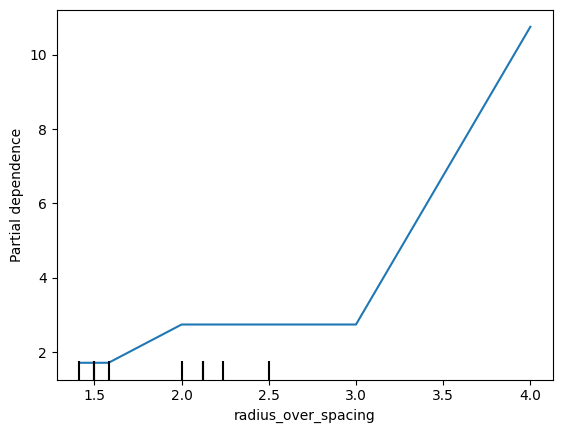

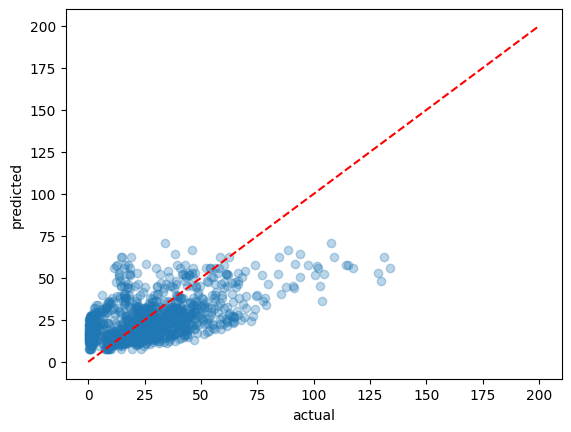

In [ ]:
# Get the fitted model out of the pipeline
gbr = model.named_steps['mdl']

# Feature importances
import pandas as pd
importances = pd.Series(gbr.feature_importances_, index=used_features).sort_values(ascending=False)
print(importances)

# How many trees, depth, etc.
print(gbr.get_params())

# Partial dependence for a single feature (e.g. radius_over_spacing)
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
PartialDependenceDisplay.from_estimator(gbr, train_df[used_features].dropna(), ['radius_over_spacing'])
plt.show()

# Actual vs predicted scatter
preds = model.predict(train_df[used_features])
plt.scatter(train_df['total_cpu_s'], preds, alpha=0.3)
plt.xlabel('actual'); plt.ylabel('predicted'); plt.plot([0,200],[0,200],'r--')
plt.show()

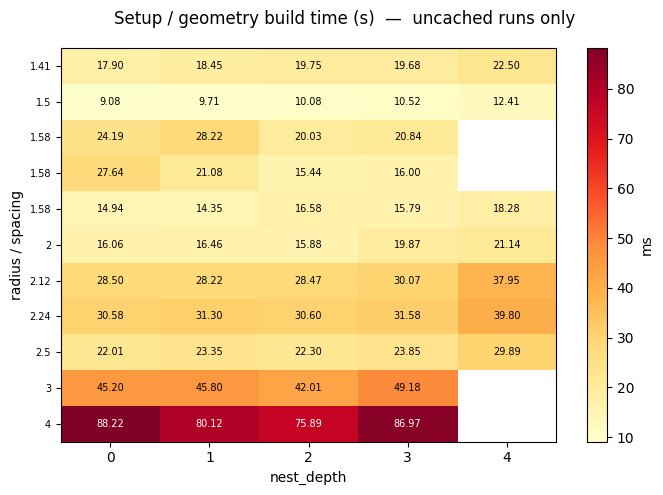

440


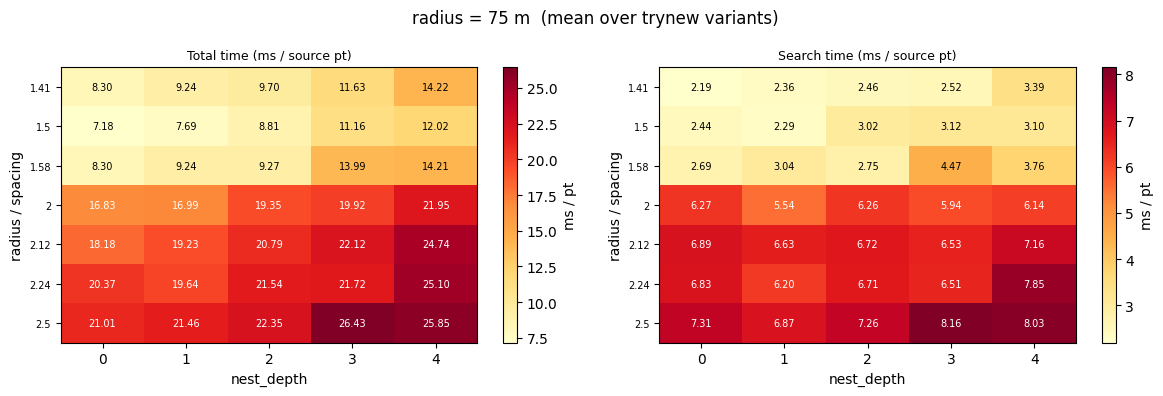

598


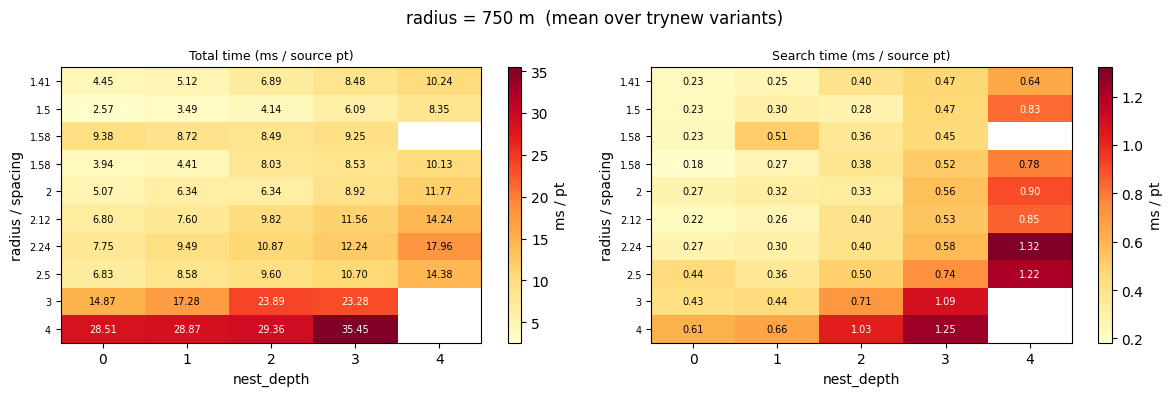

478


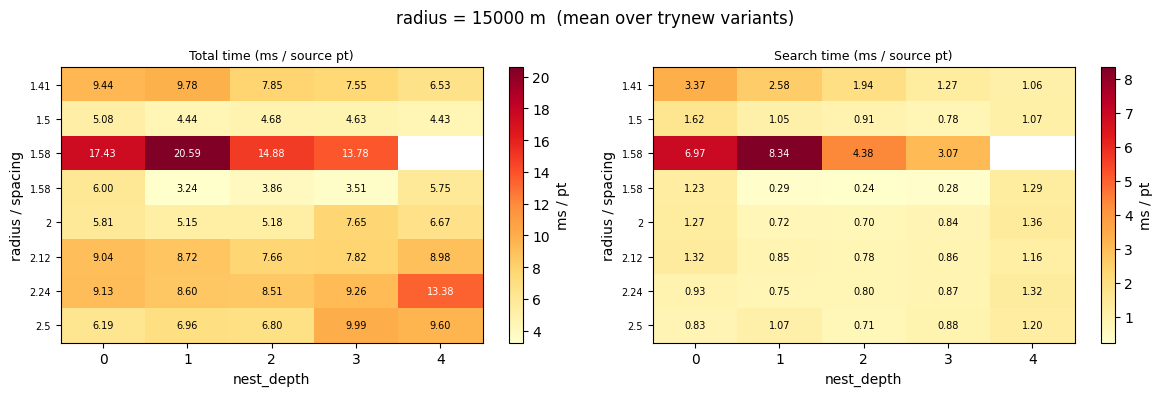


Mean ms/pt by trynew:
        total_ms_per_pt  setup_ms_per_pt  search_ms_per_pt
trynew                                                    
0                16.513           22.079             2.119
1                 4.844            2.786             1.812


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# derived per-point metrics
df["total_ms_per_pt"]  = df["total_cpu_s"] / df["n_source"] * 1000
df["setup_ms_per_pt"]  = df.get("func_build_disk_region_lookups", 0)
df["search_ms_per_pt"] = df.get("func_search_and_aggregate", 0) / df["n_source"] * 1000

df_uncached = df[df["geometry_cached"] == False]

VARIANTS = [
    ("total_ms_per_pt",  "Total time (ms / source pt)"),
    ("search_ms_per_pt", "Search time (ms / source pt)"),
]

# ── geometry build time: one plot, not per radius ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle("Setup / geometry build time (s)  —  uncached runs only", fontsize=12)

if not df_uncached.empty:
    piv = (
        df_uncached.groupby(["radius_over_spacing", "nest_depth"])["setup_ms_per_pt"]
        .mean()
        .unstack("nest_depth")
    )
    vals = piv.values.astype(float)
    if vals.size > 0 and not np.all(np.isnan(vals)):
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        plt.colorbar(im, ax=ax, label="ms")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")
    else:
        ax.set_title("(no uncached data)")
else:
    ax.set_title("(no uncached data)")

plt.tight_layout()
plt.show()

# ── per-radius plots ─────────────────────────────────────────────────────────
for r in sorted(df["radius"].unique()):
    sub = df[df["radius"] == r]
    if sub.empty:
        continue

    print(len(sub))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"radius = {r} m  (mean over trynew variants)", fontsize=12)

    for ax, (metric, title) in zip(axes, VARIANTS):
        piv = (
            sub.groupby(["radius_over_spacing", "nest_depth"])[metric]
            .mean()
            .unstack("nest_depth")
        )
        vals = piv.values.astype(float)
        if vals.size == 0 or np.all(np.isnan(vals)):
            ax.set_title(f"{title}\n(no data)", fontsize=9)
            continue
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax, label="ms / pt")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")

    plt.tight_layout()
    plt.show()

# ── trynew comparison ────────────────────────────────────────────────────────
if "trynew" in df.columns:
    print("\nMean ms/pt by trynew:")
    print(df.groupby("trynew")[["total_ms_per_pt", "setup_ms_per_pt", "search_ms_per_pt"]]
          .mean().round(3).to_string())

166


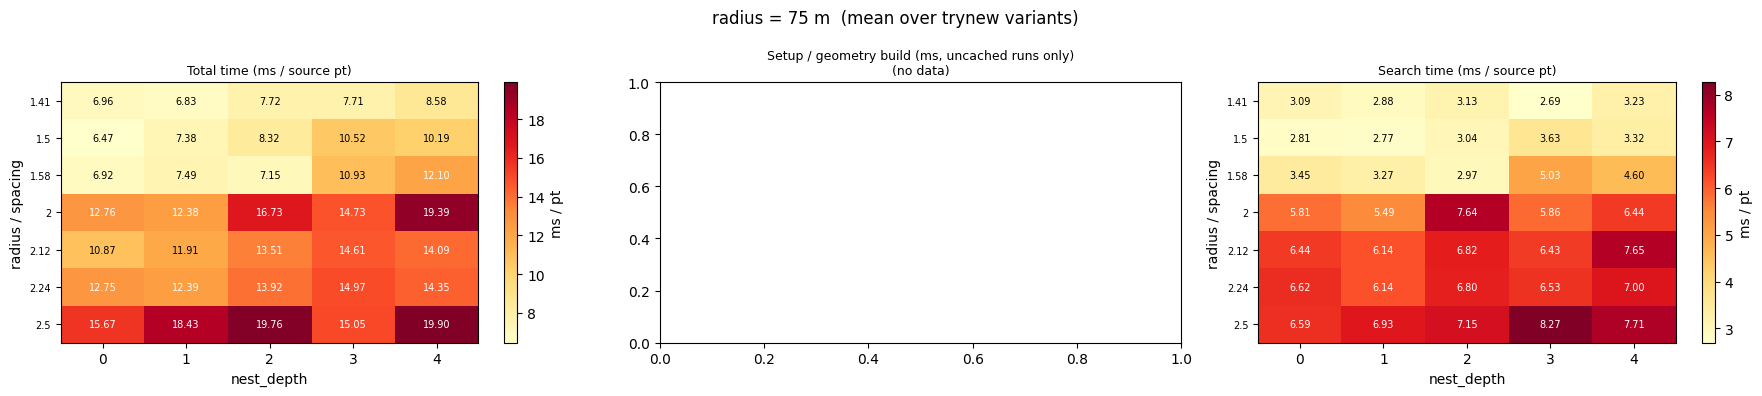

241


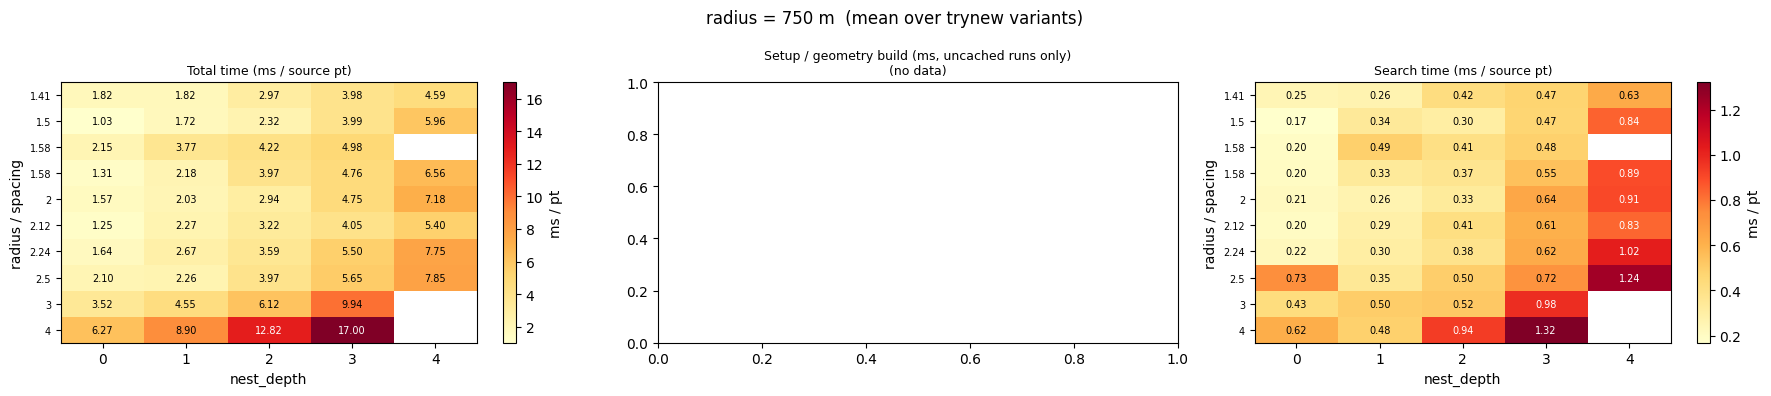

189


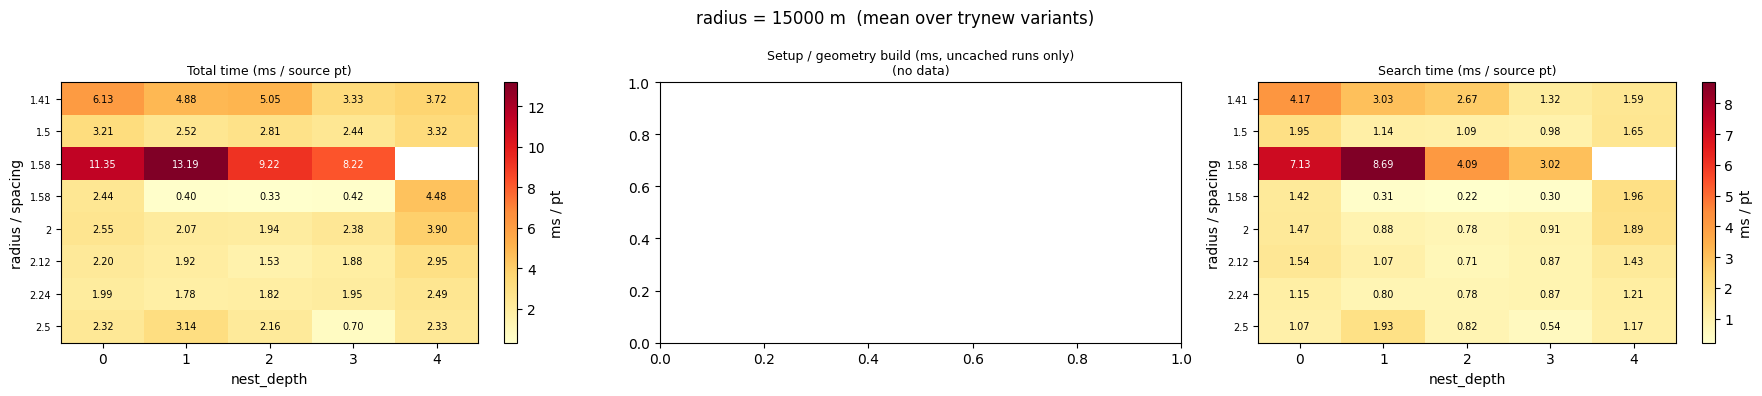


Mean ms/pt by trynew:
        total_ms_per_pt  setup_ms_per_pt  search_ms_per_pt
trynew                                                    
0                 5.871            1.736             1.980
1                 5.668            0.106             2.091


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# derived per-point metrics
df["total_ms_per_pt"]  = df["total_cpu_s"] / df["n_source"] * 1000
df["setup_ms_per_pt"]  = df.get("func_build_disk_region_lookups", 0) * 1000
df["search_ms_per_pt"] = df.get("func_search_and_aggregate", 0) / df["n_source"] * 1000

df_uncached = df[df["geometry_cached"] == False]

VARIANTS = [
    ("total_ms_per_pt",  "Total time (ms / source pt)"),
    ("setup_ms_per_pt",  "Setup / geometry build (ms, uncached runs only)"),
    ("search_ms_per_pt", "Search time (ms / source pt)"),
]

for r in sorted(df["radius"].unique()):
    sub = df[df["radius"] == r]
    sub_uncached = df_uncached[df_uncached["radius"] == r]

    print(len(sub))
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"radius = {r} m  (mean over trynew variants)", fontsize=12)

    for ax, (metric, title) in zip(axes, VARIANTS):
        src = sub_uncached if metric == "setup_ms_per_pt" else sub
        if src.empty:
            ax.set_title(f"{title}\n(no data)", fontsize=9)
            continue
        piv = (
            src.groupby(["radius_over_spacing", "nest_depth"])[metric]
            .mean()
            .unstack("nest_depth")
        )
        vals = piv.values.astype(float)
        if vals.size == 0 or np.all(np.isnan(vals)):
            ax.set_title(f"{title}\n(no data)", fontsize=9)
            continue
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax, label="ms / pt")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")

    plt.tight_layout()
    plt.show()

# trynew comparison
if "trynew" in df.columns:
    print("\nMean ms/pt by trynew:")
    print(df.groupby("trynew")[["total_ms_per_pt", "setup_ms_per_pt", "search_ms_per_pt"]]
          .mean().round(3).to_string())

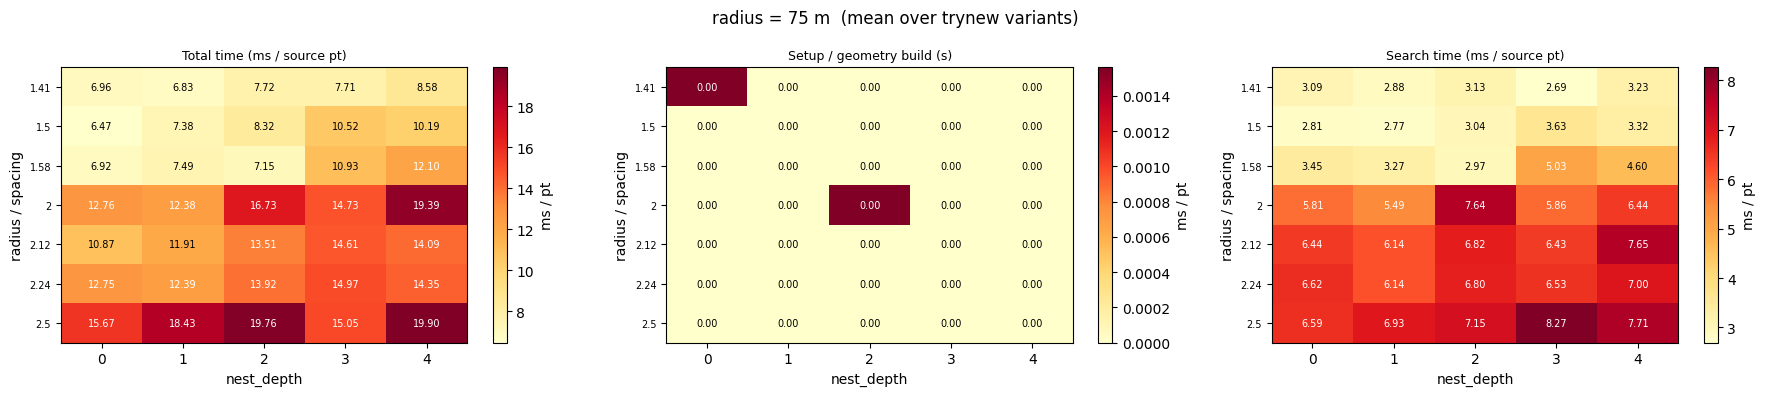

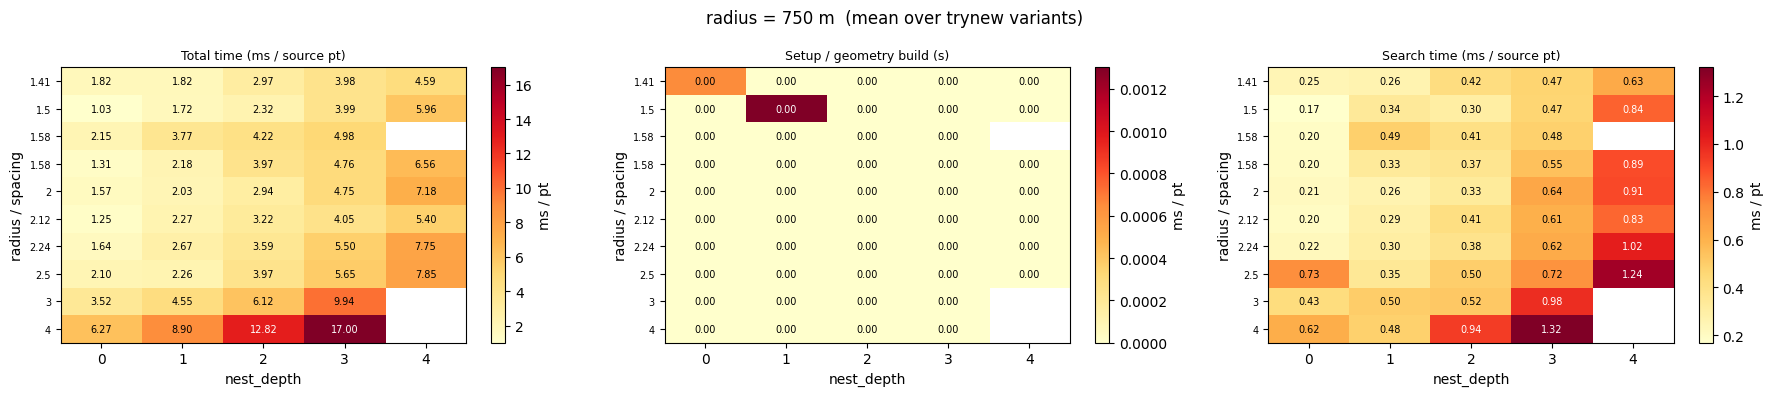

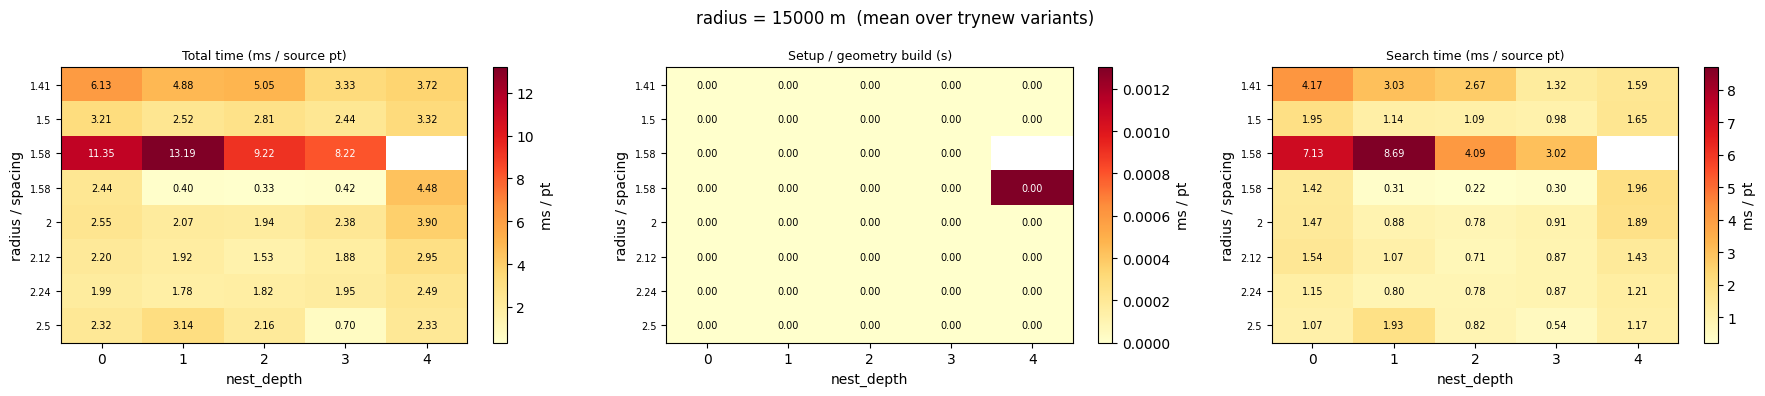


Mean ms/pt by trynew:
        total_ms_per_pt  setup_ms_per_pt  search_ms_per_pt
trynew                                                    
0                 5.871            0.001             1.980
1                 5.668            0.000             2.091


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# derived per-point metrics
df["total_ms_per_pt"]  = df["total_cpu_s"] / df["n_source"] * 1000
df["setup_ms_per_pt"]  = df.get("func_build_disk_region_lookups", 0)/ df["n_source"] * 1000
df["search_ms_per_pt"] = df.get("func_search_and_aggregate", 0) / df["n_source"] * 1000

VARIANTS = [
    ("total_ms_per_pt",  "Total time (ms / source pt)"),
    ("setup_ms_per_pt",  "Setup / geometry build (s)"),
    ("search_ms_per_pt", "Search time (ms / source pt)"),
]

for r in sorted(df["radius"].unique()):
    sub = df[(df["radius"] == r) & (df["radius_over_spacing"] <= 4) & (df["radius_over_spacing"] >= 1.4)]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"radius = {r} m  (mean over trynew variants)", fontsize=12)

    for ax, (metric, title) in zip(axes, VARIANTS):
        piv = (
            sub.groupby(["radius_over_spacing", "nest_depth"])[metric]
            .mean()
            .unstack("nest_depth")
        )
        vals = piv.values.astype(float)
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax, label="ms / pt")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")

    plt.tight_layout()
    plt.show()

# trynew comparison
if "trynew" in df.columns:
    print("\nMean ms/pt by trynew:")
    print(df.groupby("trynew")[["total_ms_per_pt", "setup_ms_per_pt", "search_ms_per_pt"]]
          .mean().round(3).to_string())

In [ ]:
df

,scenario_id,timestamp,machine_id,machine_hostname,machine_os,machine_os_version,machine_cpu,machine_cpu_count,machine_ram_gb,machine_python,...,spacing_ratio,search_cpu_s,aggregate_cpu_s,func_build_grid,log_cost,log_n,log_ros,total_ms_per_pt,setup_ms_per_pt,search_ms_per_pt
0,1b309a2d1e,2026-06-13T22:54:00,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,18.435039,NaN,NaN,2.914253,7.600902,0.458145,9.217520,0.0,4.093750
1,d99ac1b88b,2026-06-15T02:33:57,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,0.812472,NaN,NaN,-0.207674,7.600902,0.405465,0.406236,0.0,0.109375
2,0392e7e09e,2026-06-14T22:10:31,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,7.406170,NaN,NaN,2.002313,7.600902,0.458145,3.703085,0.0,3.117188
4,987d989157,2026-06-15T10:43:56,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,2.236068,0.640494,0.296875,0.0,-0.445516,7.600902,0.804719,0.320247,0.0,0.203125
6,776bae4990,2026-06-14T16:23:58,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,27.608928,NaN,NaN,3.318139,7.600902,0.405465,13.804464,0.0,1.375000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,d99ac1b88b,2026-06-15T02:45:06,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,3.968583,NaN,NaN,1.378409,7.600902,0.752039,1.984291,0.0,0.882812
1293,987d989157,2026-06-15T10:28:50,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,1.414214,0.703013,0.343750,0.0,-0.352381,7.600902,0.346574,0.351506,0.0,0.203125
1294,035c4c0634,2026-06-15T00:26:37,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,9.328072,NaN,NaN,2.233028,7.600902,0.405465,4.664036,0.0,2.789062
1295,0392e7e09e,2026-06-15T11:16:02,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,1.414214,11.828045,0.828125,0.0,2.470473,7.600902,0.346574,5.914023,0.0,2.570312


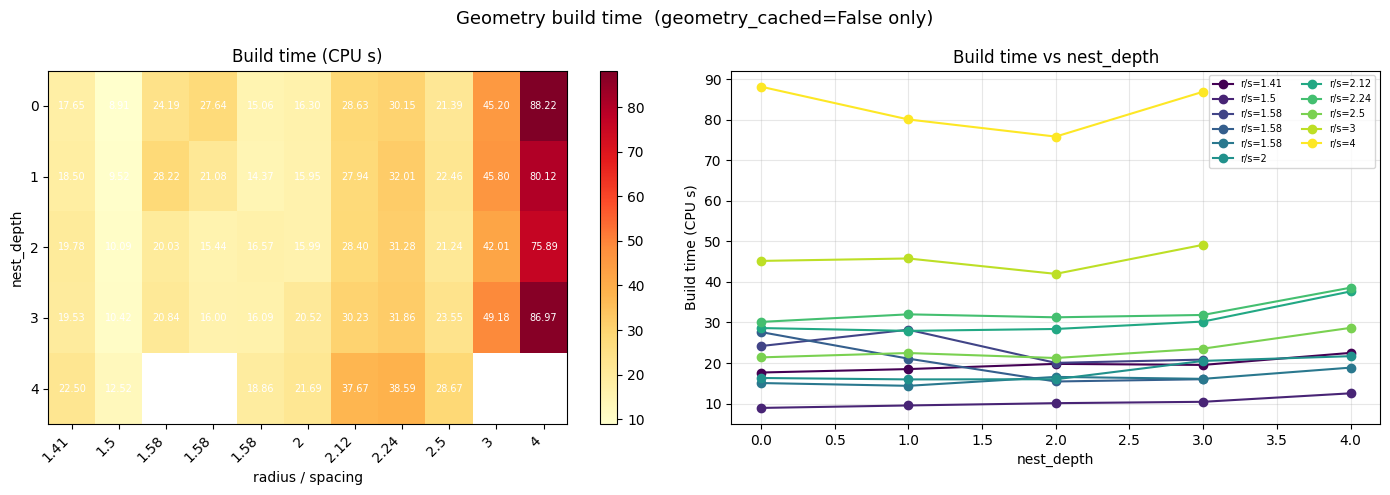

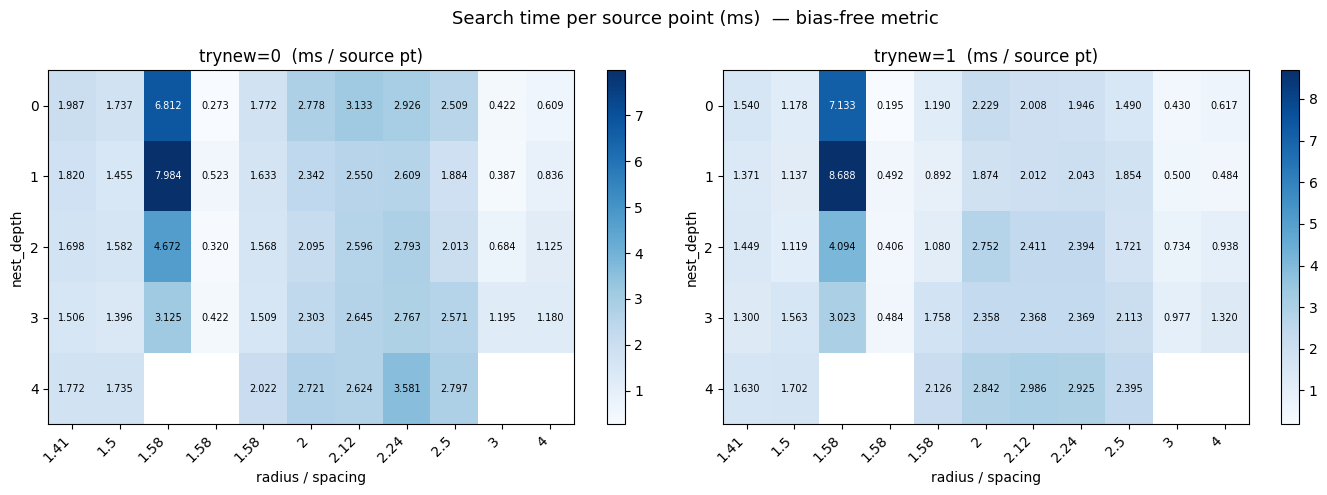

In [ ]:
import importlib.util, sys
spec = importlib.util.spec_from_file_location("perf_analysis", "perf_analysis.py")
pa = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pa)
df = pa.load_results()
sub = df[(df["radius_over_spacing"] <= 4) & (df["radius_over_spacing"] >= 1.4)]
pa.plot_build_time(sub)
pa.plot_search_time(sub)

In [ ]:
# Cell 1 — imports & geometry extractor
import sys, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "Z:/Algorithm/PL_python/AABPL-toolkit-python")
from aabpl.radius_search.disk_region_geometry import build_disk_region_lookups

def compute_static_stats(r_over_s: float, nest_depth: int) -> dict:
    """
    Build the disk region geometry for a given r/spacing ratio and nest_depth,
    then extract static geometric properties. No point data required.
    """
    t0 = time.perf_counter()
    (_, _, _, _, id_to_regions, _, sh_cntd, sh_ovlpd, lookups
     ) = build_disk_region_lookups(
        grid=None, grid_spacing=1, r=r_over_s,
        nest_depth=nest_depth, silent=True,
    )
    build_s = time.perf_counter() - t0

    def cell_area(cells):
        return sum(2 ** (-2 * lvl) for lvl, _ in cells)

    circle_area = math.pi * r_over_s ** 2

    # per-region accumulators (weighted by region area)
    total_area = 0.0
    w_cntd_count = w_ovlpd_count = 0.0
    w_cntd_area  = w_ovlpd_area  = 0.0
    mean_cntd_count = mean_ovlpd_count = 0.0
    mean_cntd_area  = mean_ovlpd_area  = 0.0
    n_reg = len(id_to_regions)

    dc = lookups["region_id_to_distinct_cntd_cells"]
    do_ = lookups["region_id_to_distinct_ovlpd_cells"]

    for reg_id, reg in id_to_regions.items():
        reg_area = reg.calc_area()
        total_area += reg_area
        cc = len(dc[reg_id]);   ca = cell_area(dc[reg_id])
        oc = len(do_[reg_id]);  oa = cell_area(do_[reg_id])
        mean_cntd_count  += cc;  mean_ovlpd_count  += oc
        mean_cntd_area   += ca;  mean_ovlpd_area   += oa
        w_cntd_count  += cc * reg_area;  w_ovlpd_count  += oc * reg_area
        w_cntd_area   += ca * reg_area;  w_ovlpd_area   += oa * reg_area

    if n_reg:
        mean_cntd_count /= n_reg;  mean_ovlpd_count /= n_reg
        mean_cntd_area  /= n_reg;  mean_ovlpd_area  /= n_reg
    if total_area:
        w_cntd_count /= total_area;  w_ovlpd_count /= total_area
        w_cntd_area  /= total_area;  w_ovlpd_area  /= total_area

    # add shared cells
    sh_cc = len(sh_cntd); sh_ca = cell_area(sh_cntd)
    sh_oc = len(sh_ovlpd); sh_oa = cell_area(sh_ovlpd)

    return dict(
        r_over_s=r_over_s, nest_depth=nest_depth,
        n_regions=n_reg,
        # mean across regions (unweighted)
        mean_cntd_count =mean_cntd_count  + sh_cc,
        mean_ovlpd_count=mean_ovlpd_count + sh_oc,
        mean_cntd_area  =mean_cntd_area   + sh_ca,
        mean_ovlpd_area =mean_ovlpd_area  + sh_oa,
        # weighted by region area
        w_cntd_count =w_cntd_count  + sh_ca,
        w_ovlpd_count=w_ovlpd_count + sh_oa,
        w_cntd_area  =w_cntd_area   + sh_ca,
        w_ovlpd_area =w_ovlpd_area  + sh_oa,
        # share of circle area (spacing² units, geometry-only)
        share_cntd =( mean_cntd_area  + sh_ca) / circle_area if circle_area else 0,
        share_ovlpd=( mean_ovlpd_area + sh_oa) / circle_area if circle_area else 0,
        build_s=build_s,
    )

In [ ]:
# Cell 2 — compute for target ratios × nest depths
R_OVER_S  = [1.5, 1.58113883, 2.0, 2.5, 3.0, 4.0]
NEST_DEPTHS = [0, 1, 2, 3, 4]

rows = []
for rs in R_OVER_S:
    for nd in NEST_DEPTHS:
        print(f"  r/s={rs:.4g}  nd={nd} ...", end=" ", flush=True)
        row = compute_static_stats(rs, nd)
        rows.append(row)
        print(f"build={row['build_s']:.1f}s  "
              f"cntd={row['mean_cntd_count']:.1f}  ovlpd={row['mean_ovlpd_count']:.1f}")

geo = pd.DataFrame(rows)
geo

  r/s=1.5  nd=0 ... 

ValueError: too many values to unpack (expected 9)

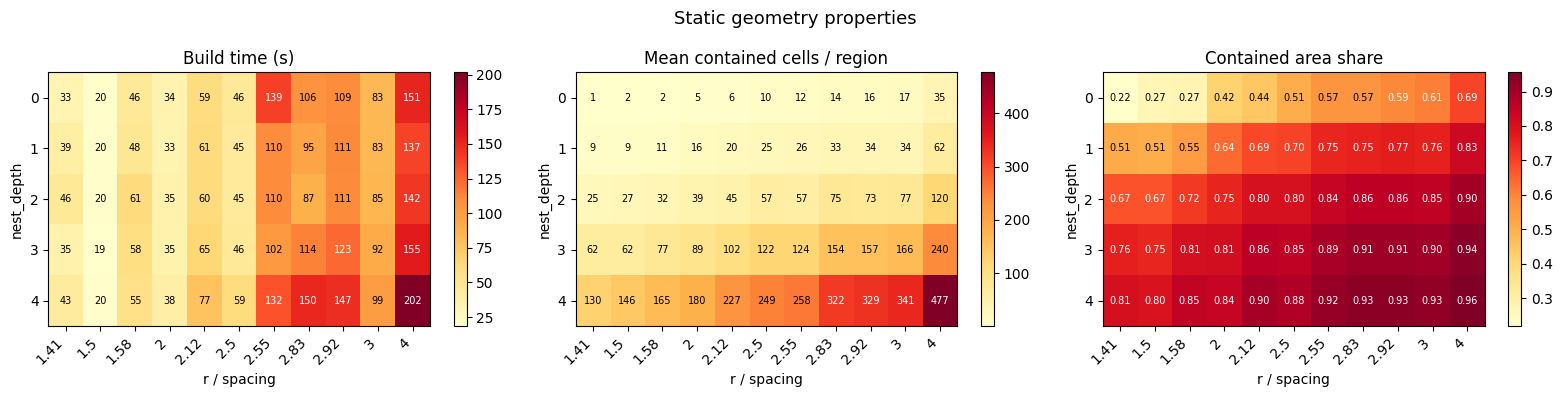

In [ ]:
# Cell 3 — build time heatmap
pivot_build = geo.pivot(index="nest_depth", columns="r_over_s", values="build_s")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Static geometry properties", fontsize=13)

for ax, col, title in zip(axes,
        ["build_s",       "mean_cntd_count",  "share_cntd"],
        ["Build time (s)", "Mean contained cells / region", "Contained area share"]):
    piv = geo.pivot(index="nest_depth", columns="r_over_s", values=col)
    im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f"{v:.3g}" for v in piv.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel("r / spacing")
    ax.set_ylabel("nest_depth")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    vmax = np.nanmax(piv.values)
    for r in range(len(piv.index)):
        for c in range(len(piv.columns)):
            v = piv.values[r, c]
            if not np.isnan(v):
                fmt = f"{v:.0f}" if col in ("build_s","mean_cntd_count") else f"{v:.2f}"
                ax.text(c, r, fmt, ha="center", va="center", fontsize=7,
                        color="white" if v > vmax * 0.6 else "black")

plt.tight_layout()
plt.show()

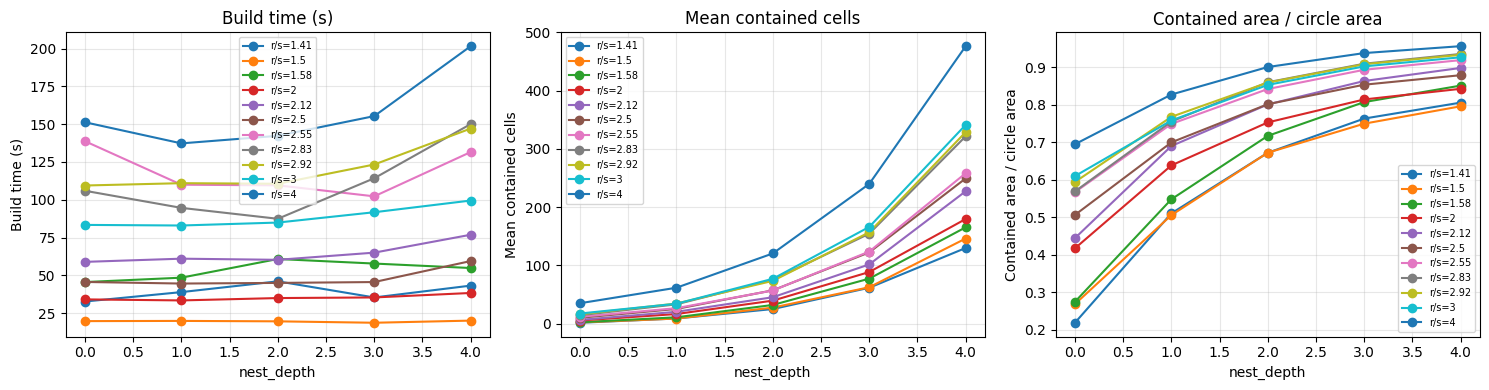

In [ ]:
# Cell 4 — build time & cell counts vs nest_depth, one line per r/s
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, ylabel in zip(axes,
        ["build_s", "mean_cntd_count", "share_cntd"],
        ["Build time (s)", "Mean contained cells", "Contained area / circle area"]):
    for rs, sub in geo.groupby("r_over_s"):
        ax.plot(sub["nest_depth"], sub[col], marker="o", label=f"r/s={rs:.3g}")
    ax.set_xlabel("nest_depth")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Prediction Models

Fit interpretable log-linear formulas for each timing component:

| Component | Target column | Data |
|---|---|---|
| Geometry build | `func_build_disk_region_lookups` | uncached runs only |
| Search | `search_cpu_s` | all runs |
| Aggregation | `aggregate_cpu_s` | all runs |
| **Total** | sum of above | — |

Formula form: `time = exp(intercept) × (r/s)^a × n^b × exp(c·nd) × …`

In [ ]:
# ── Load & prepare ────────────────────────────────────────────────────────────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
import aabpl.config as _aabpl_config
from aabpl.radius_search.spacing_topology import SPACINGS_BREAKPOINTS
PERF_FOLDER = './perf_test_gen'
df_all = load_results(PERF_FOLDER)
print(f"Total runs loaded: {len(df_all)}")
df_all["pts_per_circle"] = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"]**2
df_all["n_grid_cells"] = (
    df_all["scen_spatial_width"]  / (df_all["radius"] / df_all["radius_over_spacing"])
    * df_all["scen_spatial_height"] / (df_all["radius"] / df_all["radius_over_spacing"])
    * (4 ** df_all["nest_depth"])
)

# ── Compute total_area / circle_area from geometry cache ───────────────────
def _area_ratio(r_over_s, nest_depth):
    import math
    key = (round(r_over_s, 8), int(nest_depth), False)
    cached = _aabpl_config.disk_region_cache.get(key)
    if cached is None:
        return float("nan")
    total_area = sum(cached["region_id_to_area"].values()) or 1.0
    circle_area = math.pi * r_over_s ** 2
    return total_area / circle_area

area_ratio_map = {
    (ros, nd): _area_ratio(ros, nd)
    for ros, nd in df_all[["radius_over_spacing", "nest_depth"]].drop_duplicates().itertuples(index=False)
}
df_all["area_ratio"] = df_all.apply(
    lambda row: area_ratio_map.get((row["radius_over_spacing"], row["nest_depth"]), float("nan")),
    axis=1,
)
print(f"area_ratio computed for {df_all['area_ratio'].notna().sum()}/{len(df_all)} rows")
import numpy as np


# 2. Iteriere über die Breakpoints und erzeuge präzise Feature-Namen
ros_col_names = []
for bp in SPACINGS_BREAKPOINTS:
    # Formatiere den Spaltennamen sauber (z. B. "ros_1.4142")
    ros_col_name = f"ros_{bp:.4f}"
    ros_col_names.append(ros_col_name)
    # Berechne die absolute Differenz mit einem Toleranzfenster von 0.0001
    df_all[ros_col_name] = (np.abs(df_all['radius_over_spacing'] - bp) < 1e-4).astype(int)

df_uncached = df_all[df_all["geometry_cached"] == False].copy()
df_cached   = df_all[df_all["geometry_cached"] == True].copy()
print(f"  uncached: {len(df_uncached)}  cached: {len(df_cached)}")
print(f"  aggregate_cpu_s available: {df_all['aggregate_cpu_s'].notna().sum()} rows")


In [ ]:
# ── 4. Total time = geometry + search + aggregation ──────────────────────────
# geometry_cached runs: geometry cost = 0 (already built).
# Use df_all; predict geometry only for uncached runs.

eval_df = df_all[[
    "radius_over_spacing", "nest_depth", "trynew",
    "n_source", "n_target", "geometry_cached", "total_cpu_s",
    "pts_per_circle", "scen_density_skewness_max_to_mean", "n_grid_cells",
]].dropna().copy()

eval_df["pred_geometry"] = np.where(
    eval_df["geometry_cached"],
    0.0,
    predict_geometry(eval_df),
)
eval_df["pred_search"]    = predict_search(eval_df)
eval_df["pred_aggregate"] = predict_aggregate(eval_df)
eval_df["pred_total"]     = eval_df["pred_geometry"] + eval_df["pred_search"] + eval_df["pred_aggregate"]

mae  = (eval_df["pred_total"] - eval_df["total_cpu_s"]).abs().mean()
r2   = r2_score(eval_df["total_cpu_s"], eval_df["pred_total"])
print(f"Combined total — MAE: {mae:.3f}s   R²: {r2:.3f}   n={len(eval_df)}")

# ── Diagnostic plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Actual vs Predicted (log scale)", fontsize=12)

panels = [
    ("func_build_disk_region_lookups", "pred_geometry", "Geometry build (uncached)", df_uncached),
    ("search_cpu_s",                   "pred_search",    "Search",                   df_all),
    ("aggregate_cpu_s",                "pred_aggregate", "Aggregation",              df_all),
    ("total_cpu_s",                    "pred_total",     "Total",                    eval_df),
]

for ax, (actual_col, pred_col, title, src) in zip(axes, panels):
    merged = src.copy()
    if pred_col not in merged.columns:
        merged[pred_col] = (
            predict_geometry(merged) if pred_col == "pred_geometry" else
            predict_search(merged)   if pred_col == "pred_search"   else
            predict_aggregate(merged)
        )
    sub = merged[[actual_col, pred_col]].dropna()
    sub = sub[(sub[actual_col] > 0) & (sub[pred_col] > 0)]
    ax.scatter(sub[actual_col], sub[pred_col], alpha=0.35, s=12)
    lims = [min(sub[actual_col].min(), sub[pred_col].min()),
            max(sub[actual_col].max(), sub[pred_col].max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("actual (s)"); ax.set_ylabel("predicted (s)")
    r2_sub = r2_score(np.log(sub[actual_col]), np.log(sub[pred_col]))
    ax.set_title(f"{title}\nR²(log)={r2_sub:.3f}  n={len(sub)}", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Optimal config recommendation ─────────────────────────────────────────
# Given scenario parameters, predict total CPU time for every (sr, nd) candidate
# and return them ranked best-first.
#
# geometry_cached=True  → assume geometry already in cache (repeated calls same r/s)
# geometry_cached=False → include geometry build cost (first call for this r/s)

from aabpl.testing.perf_benchmark import compute_static_stats

def recommend_config(
    n_source: int,
    n_target: int,
    radius: float,
    spacing_ratios: list,
    nest_depths: list,
    scen_spatial_width: float,
    scen_spatial_height: float,
    scen_spatial_area: float,
    scen_density_skewness_max_to_mean: float,
    geometry_cached: bool = False,
) -> pd.DataFrame:
    """Return candidate (spacing_ratio, nest_depth) configs ranked by predicted total CPU time."""

    rows = []
    for sr in spacing_ratios:
        spacing = radius / sr
        n_gc_base = scen_spatial_width / spacing * scen_spatial_height / spacing
        pts_per_circle = n_target / scen_spatial_area * np.pi * radius ** 2
        circle_to_world = scen_spatial_width * scen_spatial_height / (np.pi * radius ** 2)

        for nd in nest_depths:
            # ensure geometry is in cache so we can look up n_regions etc.
            stats = compute_static_stats(sr, nd)

            rows.append({
                "radius_over_spacing":              sr,
                "nest_depth":                       nd,
                "n_source":                         n_source,
                "n_target":                         n_target,
                "n_grid_cells":                     n_gc_base * (4 ** nd),
                "pts_per_circle":                   pts_per_circle,
                "scen_density_skewness_max_to_mean": scen_density_skewness_max_to_mean,
                "circle_to_world":                  circle_to_world,
                "area_ratio":                       stats.get("area_ratio", float("nan")),
                "n_regions":                        stats.get("n_regions",  float("nan")),
                "mean_cntd_count":                  stats.get("mean_cntd_count", float("nan")),
                "mean_ovlpd_count":                 stats.get("mean_ovlpd_count", float("nan")),
                "trynew":                           1,
            })

    cand = pd.DataFrame(rows)
    cand["pred_geometry"]  = np.where(geometry_cached, 0.0, predict_geometry(cand))
    cand["pred_search"]    = predict_search(cand)
    cand["pred_aggregate"] = predict_aggregate(cand)
    cand["pred_total"]     = cand["pred_geometry"] + cand["pred_search"] + cand["pred_aggregate"]

    return (
        cand[["radius_over_spacing", "nest_depth",
              "pred_geometry", "pred_search", "pred_aggregate", "pred_total"]]
        .sort_values("pred_total")
        .reset_index(drop=True)
    )


# ── Example usage ──────────────────────────────────────────────────────────
_ex = df_all.iloc[0]
rec = recommend_config(
    n_source   = int(_ex["n_source"]),
    n_target   = int(_ex["n_target"]),
    radius     = float(_ex["radius"]),
    spacing_ratios = sorted(df_all["radius_over_spacing"].dropna().unique()),
    nest_depths    = sorted(df_all["nest_depth"].dropna().astype(int).unique()),
    scen_spatial_width  = float(_ex["scen_spatial_width"]),
    scen_spatial_height = float(_ex["scen_spatial_height"]),
    scen_spatial_area   = float(_ex["scen_spatial_area"]),
    scen_density_skewness_max_to_mean = float(_ex["scen_density_skewness_max_to_mean"]),
    geometry_cached = False,
)
print(f"Best config: sr={rec.iloc[0]['radius_over_spacing']:.3f}  nd={int(rec.iloc[0]['nest_depth'])}"
      f"  pred_total={rec.iloc[0]['pred_total']:.3f}s")
rec.head(10)


## Testing generation — adaptive blank-start sweep

A fresh results *generation* (own folder + label) for the current code (e.g. after
the datetime-filter change), so timings aren't mixed with older ones.

- Toggles **index** (int cell-keys vs tuple) and **loop** (plain vs vectorized+batch)
  as separate `FLAG_COMBOS`.
- `run_generation` seeds from prior results (or a coarse grid) and **recursively
  expands** around the best `(spacing_ratio, nest_depth)` per `(radius, flag)`,
  then validates the best configs at full sample size.
- Restartable: each run is saved + tagged with `GENERATION`; rerunning skips
  finished combos. `load_results(folder)` defaults to `only_new=True` (this gen only).

In [37]:
# ── New testing generation (adaptive, blank-start) ──────────────────────────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os, time
from pandas import read_csv
import aabpl.config as cfg
from aabpl.testing.perf_benchmark import run_generation, load_results
from aabpl.radius_search.spacing_topology import SPACINGS_BREAKPOINTS
# ── data ────────────────────────────────────────────────────────────────────
path_to_csv = '../../cbsa_sample_data/plants_16980.txt'
crs = "EPSG:4326"; local_crs = 'EPSG:32616'
pts = read_csv(path_to_csv, sep=",", header=None)
pts.columns = ["eid", "employment", "industry", "lat", "lon", "moved"]

# optional datetime filter (the change that motivates a new generation). 'moved'
# holds the year; 9999 is a "never moved" sentinel. Set DATETIME_COL=None to disable.
DATETIME_COL = None                       # e.g. 'moved'
DATETIME_MIN, DATETIME_MAX = None, None    # e.g. 1990, 2019
if DATETIME_COL is not None:
    s = pts[DATETIME_COL]
    if DATETIME_MIN is not None: pts = pts[s >= DATETIME_MIN]
    if DATETIME_MAX is not None: pts = pts[s <= DATETIME_MAX]
    pts = pts.reset_index(drop=True)
print(f"{len(pts):,} points after filter")

# ── search-path variants: index (int|tuple) x loop (plain|batch) ────────────

# ── exploration grid (candidate optimisation params) ────────────────────────
RADII          = [75, 750, 3000]
SPACING_RATIOS = SPACINGS_BREAKPOINTS
NEST_DEPTHS    = [0, 1, 2, 3, 4]

# ── generation bookkeeping (start from blank) ───────────────────────────────
GEN_FOLDER   = os.path.join(".", "perf_test_gen")      # fresh folder for this generation
GENERATION   = "gen" + time.strftime("%Y%m%d%H%M%S")   # unique label
PRIOR_FOLDER = os.path.join(".", "perf_test")          # older results to seed from (or None)

gen_df = run_generation(
    pts=pts, crs=crs, radii=RADII,
    spacing_ratios=SPACING_RATIOS, nest_depths=NEST_DEPTHS,
    flag_combos=None,
    screen_size=3000,
    sample_sizes=[min(50_000, len(pts))],
    col="employment", local_crs=local_crs,
    output_folder=GEN_FOLDER, generation=GENERATION,
    prior_folder=PRIOR_FOLDER if os.path.isdir(PRIOR_FOLDER) else None,
    seed_top_k=3, max_rounds=6,
    time_budget_s=8*3600,      # overnight cap (seconds); set None for no cap
    validate_top_k=2,
    silent=True, verbose=True,
)
print(f"\n{len(gen_df)} runs in generation {GENERATION}")

521,827 points after filter
=== generation gen20260618135413 ===
  grid: 3 radii x 10 spacing_ratios x 5 nest_depths x 3 flag_combos
  output: z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test_gen
  [screen] r=75 sr=1.414 nd=0 n=3000 int_batch ... Reproject from EPSG:4326 to EPSG:32616
Reproject from EPSG:4326 to EPSG:32616
35.55s
  [screen] r=75 sr=1.414 nd=3 n=3000 int_batch ... Reproject from EPSG:4326 to EPSG:32616
Reproject from EPSG:4326 to EPSG:32616
74.94s
  [screen] r=75 sr=1.414 nd=1 n=3000 int_batch ... Reproject from EPSG:4326 to EPSG:32616
Reproject from EPSG:4326 to EPSG:32616
78.58s
  [screen] r=75 sr=1.414 nd=2 n=3000 int_batch ... Reproject from EPSG:4326 to EPSG:32616
Reproject from EPSG:4326 to EPSG:32616


KeyboardInterrupt: 

In [ ]:
# ── Inspect this generation (load_results defaults to only_new=True) ────────
df = load_results(GEN_FOLDER)   # only the latest generation's rows
print(f"{len(df)} runs in generation\n")

best = (df.sort_values("total_cpu_s")
          .groupby(["radius", "use_int_cell_keys", "batch_overlap"])
          .first()[["spacing_ratio", "nest_depth", "n_source", "total_cpu_s"]])
print("Best (spacing_ratio, nest_depth) per (radius, index, loop):")
print(best.to_string())

# fastest search-path variant per radius at the largest sample size
big = df[df["n_source"] == df["n_source"].max()]
print(f"\nFastest variant per radius (n={int(df['n_source'].max())}):")
print(big.sort_values("total_cpu_s").groupby("radius").first()
        [["use_int_cell_keys", "vectorized_search_loop", "batch_overlap",
          "spacing_ratio", "nest_depth", "total_cpu_s"]].to_string())

## Flexible timing prediction model

Two-step **LASSO -> OLS** over a rich set of log-features and interactions so the
model captures non-linearities / interactions between `(r/s, nest_depth, n_src,
n_tgt, density)` while LASSO prunes the dead terms (giving interpretable power-law
exponents). Fits **geometry build** (topology-only) and the **combined
search+aggregate** per-source-point cost separately, then a `predict_total`.

Note: per-point profiling decorators are now off, so only `func_build_disk_region_lookups`
(geometry) and `func_search_and_aggregate` (search+aggregate combined) are timed —
hence one combined search+agg model rather than the old split. A GradientBoosting
CV R^2 is reported as a flexibility ceiling for comparison.

In [40]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
# ── Flexible timing model: load + derived features ──────────────────────────
import numpy as np, pandas as pd, math
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
# GEN_FOLDER='./perf_test_gen'
MODEL_FOLDER = "./perf_test_gen"#"./perf_test"
df_all = load_results(MODEL_FOLDER, only_new=False)   # all generations for fitting
print(f"{len(df_all)} runs loaded from {MODEL_FOLDER}")

# ── derived feature columns (consistent across rows; absolute units irrelevant
#    for a log-linear fit — any unit offset is absorbed by the intercept) ───────
ros = df_all["radius_over_spacing"].astype(float)
nd  = df_all["nest_depth"].astype(float)
w   = df_all["scen_spatial_width"].astype(float)
h   = df_all["scen_spatial_height"].astype(float)
df_all["n_grid_cells"]    = (w / ros) * (h / ros) * (4.0 ** nd)
df_all["pts_per_circle"]  = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"] ** 2
df_all["circle_to_world"] = (w * h) / (np.pi * ros ** 2)

# combined search+aggregate time per run (fallback chain if a column is absent)
for cand in ("func_search_and_aggregate", "total_cpu_s"):
    if cand in df_all.columns:
        df_all["search_agg_s"] = df_all[cand].astype(float); SRCH_COL = cand; break
print("search+agg target column:", SRCH_COL)

367 runs loaded from ./perf_test_gen
search+agg target column: func_search_and_aggregate


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Feature builder + LASSO->OLS fitter ─────────────────────────────────────
FEAT_NAMES = [
    # ── Topology only (no point counts) ──────────────────────────────────────
    # r/s polynomial
    "log(r/s)", "log(r/s)²", "log(r/s)³",
    # nd polynomial
    "nd", "nd²", "nd³",
    # nesting cell structure
    "log(1+4^nd)", "log(n_grid_cells)",
    # r/s × nd full cross (degree 2 in each)
    "log(r/s)×nd", "log(r/s)²×nd", "log(r/s)×nd²", "log(r/s)²×nd²",
    # grid × nd
    "log(gc)×nd",
    # log(1+4^nd) interactions
    "log(1+4^nd)×log(r/s)", "log(1+4^nd)×nd",
    ] + ros_col_names + [n+"xnd" for n in ros_col_names] + [n+"xnd²" for n in ros_col_names] + [
    # ── Point counts and density ──────────────────────────────────────────────
    "log(n_tgt)", "log(n_tgt)²",
    "log(n_src)", "log(n_src)²",
    # n_tgt × topology
    "log(n_tgt)×log(r/s)", "log(n_tgt)×nd",
    "log(n_tgt)²×log(r/s)", "log(n_tgt)²×nd",
    "log(n_tgt)×log(r/s)²", "log(n_tgt)×nd²",
    "log(n_tgt)²×log(r/s)²", "log(n_tgt)²×nd²",
    # n_src × topology
    "log(n_src)×log(r/s)", "log(n_src)×log(r/s)²",
    "log(n_src)×nd", "log(n_src)×nd²",
    # n_tgt × n_src cross
    "log(n_tgt)×log(n_src)",

    # ppc: degree 1, 2, 3 × full topology cross
    "log(ppc)",
    "log(ppc)×log(r/s)", "log(ppc)×log(r/s)²", "log(ppc)×nd", "log(ppc)×nd²",
    "log(ppc)²",
    "log(ppc)²×log(r/s)", "log(ppc)²×log(r/s)²", "log(ppc)²×nd", "log(ppc)²×nd²",
    "log(ppc)³",
    "log(ppc)³×log(r/s)", "log(ppc)³×log(r/s)²", "log(ppc)³×nd", "log(ppc)³×nd²",
    # ppc × point counts
    "log(ppc)×log(n_tgt)", "log(ppc)²×log(n_tgt)",
    "log(ppc)×log(n_src)", "log(ppc)²×log(n_src)",

    # skewness polynomial and interactions
    "log(skew)", "log(skew)²",
    "log(skew)×log(r/s)", "log(skew)×nd", "log(skew)×nd²",
    "log(skew)×log(ppc)", "log(skew)×log(ppc)²",
    "log(skew)×log(n_tgt)",

    # wrld/crcl
    "log(wrld/crcl)",
    "log(wrld/crcl)×log(r/s)", "log(wrld/crcl)×log(r/s)²",
    "log(wrld/crcl)×nd", "log(wrld/crcl)×nd²",
    "log(wrld/crcl)×log(ppc)", "log(wrld/crcl)×log(ppc)²",

    # density ratios
    "log(n_tgt/ngc)", "log(n_src/ngc)",
    "log(n_tgt/ngc)×log(r/s)", "log(n_tgt/ngc)×nd", "log(n_tgt/ngc)×nd²",
    "log(n_src/ngc)×nd",

    # ngc interactions
    "log(ppc)×log(ngc)", "log(ppc)²×log(ngc)",
    "log(ppc)×log(1+4^nd)", "log(ppc)²×log(1+4^nd)",

    # three-way interactions (selected)
    "log(ppc)×log(r/s)×nd",
    "log(n_tgt)×log(r/s)×nd",
    "n_tgt_cross_ppc",               # Raw non-log O(N^2) indicator
    "n_tgt_cross_ros",               # Raw non-log point-radius indicator
    
    # Missing crucial interactions
    "log(r/s)²×nd²",                 # Deep non-linear topology interaction
    "log(ppc)×log(r/s)²×nd",         # Density + Quadratic Radius + Depth
] + [n+"xlog(n_tgt)" for n in ros_col_names] + [n+"log(ppc)" for n in ros_col_names] + [n+"xndxlog(n_tgt)" for n in ros_col_names] + [n+"xndlog(ppc)" for n in ros_col_names]
_N_TOPO_FEATS = 15  # everything before "log(n_tgt)"


def make_X(df, include_trynew=False, ignore_npts=False):
    ros  = df["radius_over_spacing"].values
    nd   = df["nest_depth"].values
    gc   = df["n_grid_cells"].values
    lros = np.log(ros)
    lgc  = np.log(gc)
    l4nd = np.log1p(4.0 ** nd)

    cols = [
        lros, lros**2, lros**3,
        nd, nd**2, nd**3,
        l4nd, lgc,
        lros*nd, lros**2*nd, lros*nd**2, lros**2*nd**2,
        lgc*nd,
        l4nd*lros, l4nd*nd,
    ]+[df[n] for n in ros_col_names]+[df[n]*nd for n in ros_col_names]+[df[n]*nd**2 for n in ros_col_names]
    names = FEAT_NAMES[:_N_TOPO_FEATS].copy()

    if not ignore_npts:
        ppc  = df["pts_per_circle"].values
        nt=df["n_target"].values
        ns=df["n_source"].values
        lnt  = np.log(nt)
        lns  = np.log(ns)
        lppc = np.log(ppc)
        lskw = np.log(df["scen_density_skewness_max_to_mean"].values)
        lwc  = np.log(df["circle_to_world"].values)
        lngc = np.log(np.maximum(df["n_grid_cells"].values, 1.0))

        cols += [
            lnt, lnt**2,
            lns, lns**2,
            lnt*lros, lnt*nd,
            lnt**2*lros, lnt**2*nd,
            lnt*lros**2, lnt*nd**2,
            lnt**2*lros**2, lnt**2*nd**2,
            lns*lros, lns*lros**2,
            lns*nd, lns*nd**2,
            lnt*lns,

            lppc,
            lppc*lros, lppc*lros**2, lppc*nd, lppc*nd**2,
            lppc**2,
            lppc**2*lros, lppc**2*lros**2, lppc**2*nd, lppc**2*nd**2,
            lppc**3,
            lppc**3*lros, lppc**3*lros**2, lppc**3*nd, lppc**3*nd**2,
            lppc*lnt, lppc**2*lnt,
            lppc*lns, lppc**2*lns,

            lskw, lskw**2,
            lskw*lros, lskw*nd, lskw*nd**2,
            lskw*lppc, lskw*lppc**2,
            lskw*lnt,

            lwc,
            lwc*lros, lwc*lros**2,
            lwc*nd, lwc*nd**2,
            lwc*lppc, lwc*lppc**2,

            lnt - lngc,
            lns - lngc,
            (lnt - lngc)*lros, (lnt - lngc)*nd, (lnt - lngc)*nd**2,
            (lns - lngc)*nd,

            lppc*lngc, lppc**2*lngc,
            lppc*l4nd, lppc**2*l4nd,

            lppc*lros*nd,
            lnt*lros*nd,

            (nt * ppc) / 1e6,            # Scaled down to prevent scale explosions prior to StandardScaler
            (nt * ros) / 1e6,
            lros**2 * nd**2,
            lppc * (lros**2) * nd
        ]+[df[n]*lnt for n in ros_col_names]+[df[n]*lppc for n in ros_col_names]+[df[n]*nd*lnt for n in ros_col_names]+[df[n]*nd*lppc for n in ros_col_names]

        names += FEAT_NAMES[_N_TOPO_FEATS:]

    return np.column_stack(cols), names


def filter_features_by_vif(X_selected, feature_names, threshold=10.0):
    current_names = list(feature_names)
    current_indices = list(range(X_selected.shape[1])) # <- HIER: .shape[1] für Spaltenanzahl
    
    # Konstante für VIF hinzufügen (wichtig für statsmodels)
    X_vif = np.column_stack([np.ones(X_selected.shape[0]), X_selected]) # <- HIER: .shape[0] für Zeilen
    
    while True:
        if len(current_indices) <= 1:
            break
            
        vifs = []
        for i in range(1, X_vif.shape[1]): # <- HIER: .shape[1]
            try:
                vif = variance_inflation_factor(X_vif, i)
                vifs.append(vif)
            except np.linalg.LinAlgError:
                vifs.append(float('inf'))
        
        max_vif = max(vifs)
        if max_vif <= threshold:
            break
            
        max_idx = vifs.index(max_vif)
        
        X_vif = np.delete(X_vif, max_idx + 1, axis=1)
        del current_names[max_idx]
        del current_indices[max_idx]
        
    return current_indices, current_names

def lasso_then_ols(X, y, names, label, df=None, weight_n_source=False, vif_threshold=50.0):
    if weight_n_source and df is not None:
        sw_n = 1.0 / (df["n_source"].map(df["n_source"].value_counts())) ** 0.9
        sw_n = sw_n / sw_n.mean()
        sw_y = np.exp(y * 0.5)
        sw_y = sw_y / sw_y.mean()
        sample_weight = (sw_n.values * sw_y)
        sample_weight = sample_weight / sample_weight.mean()
    else:
        sample_weight = None

    # 1. LASSO auf skalierten Daten zur Feature-Auswahl
    Xs = StandardScaler().fit_transform(X)
    lasso = LassoCV(cv=5, max_iter=100000).fit(Xs, y, sample_weight=sample_weight)
    
    lasso_mask = lasso.coef_ != 0
    lasso_selected_names = [n for n, k in zip(names, lasso_mask) if k]
    X_lasso_selected = X[:, lasso_mask]
    
    # 2. VIF-Filterung zur Vermeidung von Matrix-Instabilitäten im OLS
    vif_sub_indices, final_names = filter_features_by_vif(
        X_lasso_selected, lasso_selected_names, threshold=vif_threshold
    )
    
    # Erstelle die finale, bereinigte Maske relativ zum originalen X-Datensatz
    original_indices = np.where(lasso_mask)[0]
    final_indices = original_indices[vif_sub_indices]
    
    final_mask = np.zeros(len(names), dtype=bool)
    final_mask[final_indices] = True
    
    # 3. OLS Refit auf unskalierten, kollinearitätsfreien Features
    X_final = X[:, final_mask]
    m_ols = LinearRegression().fit(X_final, y, sample_weight=sample_weight)
    
    r2 = r2_score(y, m_ols.predict(X_final))
    
    # Konsolen-Output
    removed_by_vif = lasso_mask.sum() - final_mask.sum()
    print(f"\n== {label} ==  R2={r2:.3f}  ({final_mask.sum()}/{len(names)} features) [VIF dropped {removed_by_vif}]")
    print(f"   base = exp({m_ols.intercept_:.4f})")
    for name, coef in zip(final_names, m_ols.coef_):
        print(f"     x exp({coef:+.3f} * {name})")
        
    return final_mask, m_ols

def lasso_predict(df, mask, m_ols, ignore_npts=False):
    X, _ = make_X(df, ignore_npts=ignore_npts)
    return np.exp(m_ols.predict(X[:, mask]))

In [42]:
# ── Fit geometry (topology-only) and combined search+aggregate ──────────────
geo = df_all[~df_all["geometry_cached"].astype(bool)].copy() if "geometry_cached" in df_all else df_all.copy()
has_geo = "func_build_disk_region_lookups" in df_all.columns and len(geo) > 5

if has_geo:
    Xg, ng = make_X(geo, ignore_npts=True)
    mask_geo, m_geo = lasso_then_ols(Xg, np.log(geo["func_build_disk_region_lookups"].astype(float)),
                                     ng, "Geometry build (topology only)", df=geo)
    def predict_geometry(df): return lasso_predict(df, mask_geo, m_geo, ignore_npts=True)
else:
    print("(no geometry-build timing available; skipping geometry model)")
    def predict_geometry(df): return np.zeros(len(df))

# Search — absolute seconds
fit_s = df_all[df_all["search_cpu_s"].astype(float) > 0]
ys = np.log(fit_s["search_cpu_s"].astype(float))
Xs, ns = make_X(fit_s, ignore_npts=False)
mask_s, m_s = lasso_then_ols(Xs, ys, ns, "Search (absolute s)", df=fit_s, weight_n_source=True)
def predict_search(df): return lasso_predict(df, mask_s, m_s, ignore_npts=False)

# Aggregation — absolute seconds
fit_a = df_all[df_all["aggregate_cpu_s"].astype(float) > 0]
ya = np.log(fit_a["aggregate_cpu_s"].astype(float))
Xa, na = make_X(fit_a, ignore_npts=False)
mask_a, m_a = lasso_then_ols(Xa, ya, na, "Aggregation (absolute s)", df=fit_a, weight_n_source=True)
def predict_aggregate(df): return lasso_predict(df, mask_a, m_a, ignore_npts=False)

def predict_total(df):
    geo_s = predict_geometry(df) * (~df["geometry_cached"].astype(bool)).values if "geometry_cached" in df else predict_geometry(df)
    return geo_s + predict_search(df) + predict_aggregate(df)


== Geometry build (topology only) ==  R2=0.435  (2/15 features)
   base = exp(2.4772)
     x exp(+0.865 * log(r/s)³)
     x exp(+0.003 * nd³)


c:\Users\econometrics\anaconda3\envs\primelocations\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.016238e-01, tolerance: 8.836e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\econometrics\anaconda3\envs\primelocations\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.977629e-01, tolerance: 8.836e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\econometrics\anaconda3\envs\primelocations\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check 


== Search (absolute s) ==  R2=-0.350  (35/78 features)
   base = exp(59.2641)
     x exp(-3.872 * log(r/s)³)
     x exp(+0.060 * nd³)
     x exp(-0.687 * log(n_grid_cells))
     x exp(+2.289 * log(r/s)²×nd)
     x exp(-0.343 * log(r/s)×nd²)
     x exp(-0.188 * log(r/s)²×nd²)
     x exp(+0.017 * log(n_tgt)²)
     x exp(-1.596 * log(n_src))
     x exp(+0.098 * log(n_src)²)
     x exp(+0.000 * log(n_tgt)²×nd²)
     x exp(+0.067 * log(n_tgt)×log(n_src))
     x exp(-1.381 * log(ppc)×log(r/s)²)
     x exp(+0.116 * log(ppc)×nd)
     x exp(-0.116 * log(ppc)×nd²)
     x exp(+0.667 * log(ppc)²×log(r/s)²)
     x exp(-0.021 * log(ppc)³)
     x exp(-0.096 * log(ppc)³×log(r/s))
     x exp(-0.004 * log(ppc)³×nd)
     x exp(+0.003 * log(ppc)³×nd²)
     x exp(-0.463 * log(ppc)×log(n_tgt))
     x exp(+0.060 * log(ppc)²×log(n_tgt))
     x exp(-0.461 * log(ppc)×log(n_src))
     x exp(+0.061 * log(ppc)²×log(n_src))
     x exp(+1.246 * log(skew))
     x exp(+0.044 * log(skew)²)
     x exp(+0.191 * log(skew

In [32]:
# ── Flexibility ceiling: GradientBoosting CV R^2 (non-parametric, captures any
#    interaction/non-linearity) — compare against the LASSO->OLS log-linear model.
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

RAW_FEATS = ["radius_over_spacing", "nest_depth", "n_grid_cells", "n_source", "n_target",
             "pts_per_circle", "circle_to_world", "scen_density_skewness_max_to_mean"]
RAW_FEATS = [c for c in RAW_FEATS if c in df_all.columns]
Xr = np.log(np.clip(df_all[RAW_FEATS].astype(float).values, 1e-12, None))
y_sa = np.log((df_all["search_agg_s"] / df_all["n_source"]).astype(float))

gbr = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                                subsample=0.8, random_state=0)
cv = cross_val_score(gbr, Xr, y_sa, cv=5, scoring="r2")
print(f"GBM 5-fold CV R2 (search+agg, log): {cv.mean():.3f} +/- {cv.std():.3f}")
gbr.fit(Xr, y_sa)
imp = pd.Series(gbr.feature_importances_, index=RAW_FEATS).sort_values(ascending=False)
print("\nGBM feature importances:"); print(imp.to_string())

GBM 5-fold CV R2 (search+agg, log): 0.941 +/- 0.012

GBM feature importances:
pts_per_circle                       0.596948
n_target                             0.110665
n_source                             0.101509
nest_depth                           0.073349
circle_to_world                      0.062427
n_grid_cells                         0.022625
scen_density_skewness_max_to_mean    0.018612
radius_over_spacing                  0.013864
